# Perguntas Analiticas - Passos Magicos Datathon

## Objetivo
Responder 11 perguntas de negocio usando o dataset limpo e unificado.

## Fonte oficial
- data/dados_unificados.csv

## Perguntas
1. Perfil e evolucao do IAN
2. Tendencia de desempenho do IDA
3. Correlacao entre IEG, IDA e IPV
4. Alinhamento entre IAA e IDA
5. Padroes de risco psicossocial (IPS)
6. Consistencia entre IAN e IPP
7. Melhores preditores de IPV
8. Combinacoes de indicadores que elevam INDE
9. Sinais precoces de risco academico
10. Evolucao de desempenho entre fases
11. Insights adicionais


In [2]:
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.notebook_utils import make_figure_saver, prepare_analytical_dataset, load_official_dataset

df, data_path, project_root = load_official_dataset(project_root=project_root)
df = prepare_analytical_dataset(df)

print(f"Fonte: {data_path.name}")
print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
if df["ano"].notna().any():
    anos_validos = sorted(df["ano"].dropna().astype(int).unique().tolist())
    print(f"Anos no dataset: {anos_validos}")
if "inde_unificado" in df.columns:
    pct_inde = df["inde_unificado"].notna().mean() * 100
    print(f"Cobertura de inde_unificado: {pct_inde:.1f}%")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#f8f9fa"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
sns.set_theme(style="whitegrid")

# Paleta azul/cinza com contraste
COR_VERMELHO = "#0b2e59"
COR_LARANJA = "#5f738c"
COR_VERDE = "#b6c5d8"
COR_AZUL = "#123a66"
COR_AZUL_CLARO = "#d7e1ed"
COR_TEXTO = "#1f2937"
PALETA = [COR_AZUL, COR_AZUL_CLARO, COR_VERDE, COR_LARANJA, COR_VERMELHO]

fig_dir, salvar_figura = make_figure_saver(project_root)

if {"ano", "phase", "fase_padronizada"}.issubset(df.columns):
    base_phase = df.dropna(subset=["ano"]).copy()
    base_phase["ano"] = base_phase["ano"].astype(int)
    print("\nChecagem de normalizacao de fase por ano:")
    chk = base_phase.groupby("ano").agg(
        phase_bruta_unicas=("phase", "nunique"),
        fase_padronizada_unicas=("fase_padronizada", "nunique")
    )
    print(chk)

Fonte: dados_unificados.csv
Shape: 3030 linhas x 35 colunas
Anos no dataset: [2022, 2023, 2024]
Cobertura de inde_unificado: 93.9%

Checagem de normalizacao de fase por ano:
      phase_bruta_unicas  fase_padronizada_unicas
ano                                              
2022                   8                        8
2023                   9                        9
2024                  72                       10


## Q1: Perfil e Evolução do IAN

**Pergunta:** Adequação do nível (IAN): qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?
Exemplo: quantos alunos estão moderadamente ou severamente defasados?

**Nota metodológica (critério oficial PEDE):**

**Categorias de proficiência em IAN (escala discreta observada na base):**
- **Defasagem severa**: IAN ≤ 2.5
- **Defasagem moderada**: IAN = 5
- **Fase adequada**: IAN = 10 (alunos alinhados com a série ideal)

**Operacionalizando para leitura executiva nesta análise:**
- **Defasagem total**: IAN ≤ 5 = (severa + moderada)
- **Defasagem severa** (subcategoria): IAN ≤ 2.5

In [ ]:
if 'ian' not in df.columns:
    print('Coluna IAN nao encontrada.')
else:
    tmp = df.copy()
    tmp = tmp.dropna(subset=['ian', 'ano']).copy()
    tmp['ano'] = tmp['ano'].astype(int)

    # Fallback de cores caso a celula de setup nao tenha sido reexecutada
    cor_vermelho = globals().get('COR_VERMELHO', '#0b2e59')
    cor_laranja = globals().get('COR_LARANJA', '#5f738c')
    cor_verde = globals().get('COR_VERDE', '#b6c5d8')

    # Pasta de saida para figuras
    fig_dir = project_root / 'outputs' / 'figuras'
    fig_dir.mkdir(parents=True, exist_ok=True)

    # Criterio oficial PEDE para IAN
    condicoes = [
        tmp['ian'] <= 2.5,
        tmp['ian'] == 5,
        tmp['ian'] == 10
    ]
    categorias = ['Defasagem severa', 'Defasagem moderada', 'Fase adequada']
    tmp['categoria_ian'] = np.select(condicoes, categorias, default=np.nan)

    print('Criterio de classificacao adotado (PEDE):')
    print('- Defasagem severa: IAN <= 2.5')
    print('- Defasagem moderada: IAN = 5')
    print('- Fase adequada: IAN = 10')

    dist_geral = tmp['categoria_ian'].value_counts(dropna=False).rename('contagem').to_frame()
    dist_geral['percentual'] = (dist_geral['contagem'] / dist_geral['contagem'].sum() * 100).round(2)
    print('\nDistribuicao geral de categorias do IAN:')
    print(dist_geral)

    resumo_ano = tmp.groupby('ano')['ian'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)
    print('\nResumo do IAN por ano:')
    print(resumo_ano)

    dist_ano = (
        pd.crosstab(tmp['ano'], tmp['categoria_ian'], normalize='index')
        .mul(100)
        .round(2)
        .reindex(columns=categorias)
    )
    dist_ano['Defasagem total'] = (
        dist_ano['Defasagem severa'].fillna(0) + dist_ano['Defasagem moderada'].fillna(0)
    ).round(2)
    dist_ano['Defasagem severa pct'] = dist_ano['Defasagem severa'].fillna(0).round(2)

    print('\nPercentual por categoria do IAN por ano:')
    print(dist_ano)

    anos_ord = sorted(dist_ano.index.tolist())

    # Complemento analitico: risco por fase e por ano-fase
    fase_col = 'fase_padronizada' if 'fase_padronizada' in tmp.columns else ('phase' if 'phase' in tmp.columns else None)
    if fase_col is not None:
        base_fase = tmp[tmp[fase_col].notna()].copy()
        base_fase['risco_total'] = (base_fase['ian'] <= 5).astype(int)

        risco_fase = (
            base_fase.groupby(fase_col)['risco_total']
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .round(2)
        )
        print('\nRisco total de defasagem por fase (geral):')
        print(risco_fase)

        risco_fase_ano = (
            base_fase.groupby([fase_col, 'ano'])['risco_total']
            .mean()
            .mul(100)
            .unstack()
            .reindex(columns=anos_ord)
        )

        print('\nRisco total de defasagem por fase e ano:')
        print(risco_fase_ano.round(2))

        ano_recente = max(anos_ord)
        top_fases = (
            base_fase[base_fase['ano'] == ano_recente]
            .groupby(fase_col)['risco_total']
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(8)
        )

        if not top_fases.empty:
            fig, ax = plt.subplots(figsize=(9, max(5, len(top_fases) * 0.5)))
            ax.barh(top_fases.index.astype(str), top_fases.values, color=cor_laranja)
            ax.invert_yaxis()
            ax.set_title(f'Q1 - Fases com maior risco de defasagem em {ano_recente}')
            ax.set_xlabel('Taxa de risco total (%)')
            ax.set_ylabel('Fase')
            ax.grid(axis='x', alpha=0.18)
            plt.tight_layout()
            salvar_figura(fig, 'q1_top_fases_risco_ano_recente.png')
            plt.show()

        risco_fase_ano_valid = risco_fase_ano.dropna(how='all').dropna(thresh=2, axis=0)
        if not risco_fase_ano_valid.empty:
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.heatmap(
                risco_fase_ano_valid,
                annot=True,
                fmt='.1f',
                cmap='Blues',
                linewidths=0.4,
                linecolor='white',
                ax=ax
            )
            ax.set_title('Q1 - Risco total de defasagem por fase e ano')
            ax.set_xlabel('Ano')
            ax.set_ylabel('Fase')
            plt.tight_layout()
            salvar_figura(fig, 'q1_heatmap_risco_fase_ano.png')
            plt.show()

    # Ordem invertida do empilhamento: fase adequada embaixo, severa em cima
    ordem_plot = ['Fase adequada', 'Defasagem moderada', 'Defasagem severa']
    cores_plot = [cor_verde, cor_laranja, cor_vermelho]

    fig, ax = plt.subplots(figsize=(9, 5))
    dist_ano[ordem_plot].plot(
        kind='bar',
        stacked=True,
        color=cores_plot,
        edgecolor='white',
        linewidth=0.8,
        ax=ax
    )
    ax.set_title('Q1 - Perfil de defasagem (IAN) por ano', pad=14)
    ax.set_xlabel('Ano', labelpad=6)
    ax.set_ylabel('Percentual de alunos (%)')
    ax.set_xticklabels([str(int(x)) for x in anos_ord], rotation=0)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
    ax.grid(False)

    # Labels por categoria para facilitar leitura, inclusive em segmentos pequenos
    bottoms = np.zeros(len(dist_ano))
    max_label_y = 100.0
    for cat in ordem_plot:
        valores = dist_ano[cat].values
        for i, v in enumerate(valores):
            if v <= 0:
                continue
            if cat == 'Fase adequada':
                txt_color = '#1f2937'
                txt_weight = 'normal'
                txt_bbox = None
            elif cat == 'Defasagem severa':
                txt_color = '#ffffff'
                txt_weight = 'bold'
                txt_bbox = None
            else:
                txt_color = '#ffffff'
                txt_weight = 'normal'
                txt_bbox = None
            if cat == 'Defasagem severa' and v < 2:
                y = bottoms[i] + v + 0.35
                va = 'bottom'
                txt_color = '#1f2937'
                txt_weight = 'bold'
                txt_bbox = dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.12')
            elif v < 3:
                y = bottoms[i] + (v / 2)
                va = 'center'
            else:
                y = bottoms[i] + v / 2
                va = 'center'
            max_label_y = max(max_label_y, y)
            ax.text(i, y, f'{v:.1f}%', ha='center', va=va, fontsize=10, color=txt_color, fontweight=txt_weight, bbox=txt_bbox)
        bottoms += valores
    ax.set_ylim(0, max(106, max_label_y + 3.0))

    fig.tight_layout(rect=[0, 0.14, 1, 0.96])
    salvar_figura(fig, 'q1_perfil_defasagem_por_ano.png')
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.lineplot(
        x=dist_ano.index,
        y=dist_ano['Defasagem total'],
        marker='o',
        linewidth=2.5,
        color=cor_laranja,
        label='Defasagem total',
        ax=ax
    )
    sns.lineplot(
        x=dist_ano.index,
        y=dist_ano['Defasagem severa pct'],
        marker='o',
        linewidth=2.2,
        color=cor_vermelho,
        label='Defasagem severa',
        ax=ax
    )
    ax.set_title('Q1 - Evolucao da defasagem ao longo do tempo')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Percentual (%)')
    ax.set_xticks(anos_ord)
    ax.set_xticklabels([str(a) for a in anos_ord])
    ax.grid(axis='y', alpha=0.2)
    ax.legend()
    plt.tight_layout()
    salvar_figura(fig, 'q1_evolucao_taxas_defasagem.png')
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.bar(dist_ano.index.astype(int), dist_ano['Defasagem total'].values, color=cor_laranja)
    ax.set_title('Q1 - Taxa de defasagem total por ano')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Defasagem total (%)')
    ax.set_xticks(anos_ord)
    ax.set_xticklabels([str(a) for a in anos_ord])
    ax.grid(axis='y', alpha=0.2)
    for x, y in zip(anos_ord, dist_ano['Defasagem total'].values):
        ax.text(x, y + 0.6, f'{y:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    salvar_figura(fig, 'q1_barras_defasagem_total_ano.png')
    plt.show()

    variacao_risco = dist_ano['Defasagem total'].iloc[-1] - dist_ano['Defasagem total'].iloc[0]
    print('\nO que observamos:')
    if variacao_risco < 0:
        print(f'- A taxa de defasagem total caiu {abs(variacao_risco):.2f} p.p. no periodo analisado.')
    else:
        print(f'- A taxa de defasagem total subiu {variacao_risco:.2f} p.p. no periodo analisado.')
    print('- A media total ajuda, mas o detalhamento por fase mostra onde o risco esta mais concentrado.')
    print(f'Figuras salvas em: {fig_dir}')

## Q2: Tendencia de Desempenho do IDA

**Pergunta:** O desempenho academico medio (IDA) esta melhorando, estagnado ou caindo ao longo das fases e anos?

**Hipotese operacional:** parte da variacao anual pode vir de mudanca no mix de fases (composicao), e nao apenas de ganho pedagogico intrafase.

**Leitura para decisao:**
- se o IDA observado sobe, mas o IDA ajustado por fase nao sobe no mesmo ritmo, o efeito de composicao esta relevante;
- metas de gestao devem separar ganho intrafase de ganho por redistribuicao de perfil.

**Cuidado de interpretacao:** esta secao e descritiva/inferencial de associacao temporal; nao estabelece causalidade por si so.

IDA por ano:
      count   mean    std   ci95
ano                             
2022    860  6.093  2.046  0.137
2023    937  6.663  1.595  0.102
2024   1055  6.351  2.132  0.129

Tendencia anual estimada (WLS): slope=+0.1144 ponto/ano | p-valor=0.7300

IDA ajustada por composicao de fases:
ano
2022    5.001
2023    6.121
2024    5.938
dtype: float64

Decomposicao da variacao total no periodo:
- Efeito intrafase (ganho real): +0.310
- Efeito composicao (mudanca de mix): +0.158
Figura salva: q2_ida_tendencia_observado_ajustado.png


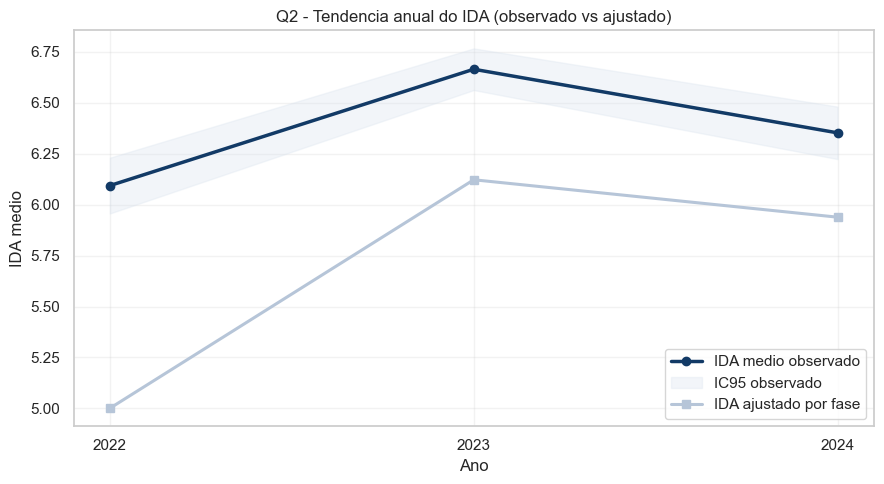

Figura salva: q2_ida_dispersao_por_ano.png


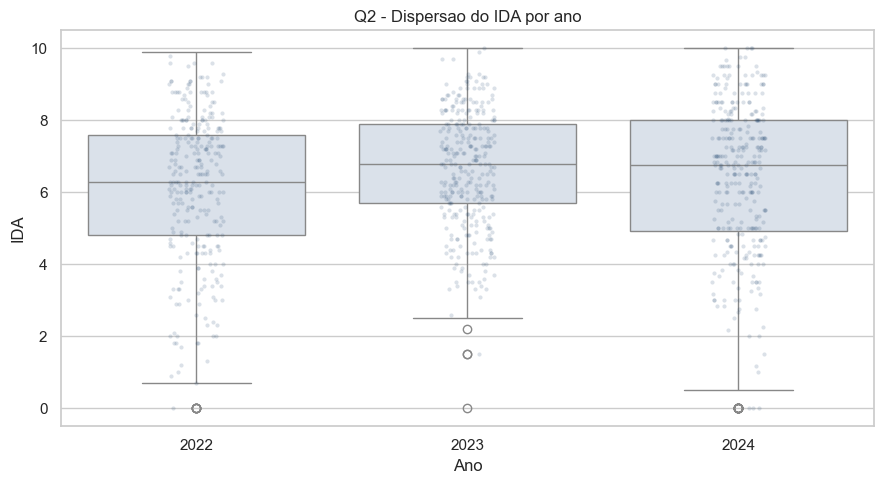


O que observamos (Q2):
- Diagnostico: IDA estagnado/oscila; variacao acumulada no periodo = +0.259.
- Leitura executiva: o ajuste por composicao separa melhora real de possiveis mudancas de mix entre fases.
- Acao: metas anuais devem considerar ganho intrafase e nao apenas media agregada.


In [3]:
if 'ida' not in df.columns:
    print('Coluna IDA nao encontrada.')
else:
    import statsmodels.api as sm

    fase_col = 'fase_padronizada' if 'fase_padronizada' in df.columns else ('phase' if 'phase' in df.columns else None)
    tmp = df.dropna(subset=['ida', 'ano']).copy()
    tmp['ano'] = tmp['ano'].astype(int)

    if tmp.empty:
        print('Sem dados validos para Q2 apos filtros.')
    else:
        resumo = (
            tmp.groupby('ano')['ida']
            .agg(['count', 'mean', 'std'])
            .sort_index()
        )
        resumo['sem'] = resumo['std'] / np.sqrt(resumo['count'])
        resumo['ci95'] = 1.96 * resumo['sem']

        anos_ord = resumo.index.tolist()
        year_num = np.array(anos_ord, dtype=float)
        y_mean = resumo['mean'].values

        # Tendencia agregada via regressao linear ponderada por volume anual
        x = sm.add_constant(year_num)
        wls = sm.WLS(y_mean, x, weights=resumo['count'].values).fit()
        slope = float(wls.params[1])
        p_slope = float(wls.pvalues[1]) if len(wls.pvalues) > 1 else np.nan

        # Ajuste por composicao de fase para separar efeito de mix vs ganho real
        ida_ajustada = None
        comp_effect = np.nan
        within_effect = np.nan
        if fase_col is not None and fase_col in tmp.columns:
            base_phase = tmp.dropna(subset=[fase_col]).copy()
            phase_w = base_phase[fase_col].value_counts(normalize=True)
            phase_year = (
                base_phase.groupby(['ano', fase_col])['ida']
                .mean()
                .rename('ida_media')
                .reset_index()
            )
            piv = phase_year.pivot(index='ano', columns=fase_col, values='ida_media')
            common_cols = [c for c in piv.columns if c in phase_w.index]
            if common_cols:
                w = phase_w[common_cols]
                ida_ajustada = piv[common_cols].mul(w, axis=1).sum(axis=1) / w.sum()

                ano_ini, ano_fim = anos_ord[0], anos_ord[-1]
                mix_ini = base_phase[base_phase['ano'] == ano_ini][fase_col].value_counts(normalize=True)
                mix_fim = base_phase[base_phase['ano'] == ano_fim][fase_col].value_counts(normalize=True)
                media_fim_por_fase = piv.loc[ano_fim].dropna()
                common_mix = [c for c in media_fim_por_fase.index if c in mix_ini.index and c in mix_fim.index]
                if common_mix:
                    within_effect = float((media_fim_por_fase[common_mix] * mix_ini[common_mix]).sum() - (piv.loc[ano_ini, common_mix] * mix_ini[common_mix]).sum())
                    comp_effect = float((media_fim_por_fase[common_mix] * (mix_fim[common_mix] - mix_ini[common_mix])).sum())

        print('IDA por ano:')
        print(resumo[['count', 'mean', 'std', 'ci95']].round(3))
        print(f'\nTendencia anual estimada (WLS): slope={slope:+.4f} ponto/ano | p-valor={p_slope:.4f}')

        if ida_ajustada is not None:
            print('\nIDA ajustada por composicao de fases:')
            print(ida_ajustada.round(3))
            if pd.notna(within_effect) and pd.notna(comp_effect):
                print(f'\nDecomposicao da variacao total no periodo:')
                print(f'- Efeito intrafase (ganho real): {within_effect:+.3f}')
                print(f'- Efeito composicao (mudanca de mix): {comp_effect:+.3f}')

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(anos_ord, resumo['mean'].values, marker='o', linewidth=2.5, color=COR_AZUL, label='IDA medio observado')
        ax.fill_between(
            anos_ord,
            (resumo['mean'] - resumo['ci95']).values,
            (resumo['mean'] + resumo['ci95']).values,
            color=COR_AZUL_CLARO,
            alpha=0.30,
            label='IC95 observado'
        )
        if ida_ajustada is not None:
            ax.plot(ida_ajustada.index.astype(int), ida_ajustada.values, marker='s', linewidth=2.2, color=COR_VERDE, label='IDA ajustado por fase')
        ax.set_title('Q2 - Tendencia anual do IDA (observado vs ajustado)')
        ax.set_xlabel('Ano')
        ax.set_ylabel('IDA medio')
        ax.set_xticks(anos_ord)
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        salvar_figura(fig, 'q2_ida_tendencia_observado_ajustado.png')
        plt.show()

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.boxplot(data=tmp, x='ano', y='ida', color=COR_AZUL_CLARO, ax=ax)
        sns.stripplot(data=tmp.sample(min(len(tmp), 900), random_state=42), x='ano', y='ida', color=COR_AZUL, alpha=0.15, size=3, ax=ax)
        ax.set_title('Q2 - Dispersao do IDA por ano')
        ax.set_xlabel('Ano')
        ax.set_ylabel('IDA')
        plt.tight_layout()
        salvar_figura(fig, 'q2_ida_dispersao_por_ano.png')
        plt.show()

        variacao_total = float(resumo['mean'].iloc[-1] - resumo['mean'].iloc[0])
        status = 'melhorando' if slope > 0 and p_slope < 0.05 else ('caindo' if slope < 0 and p_slope < 0.05 else 'estagnado/oscila')
        print('\nO que observamos (Q2):')
        print(f'- Diagnostico: IDA {status}; variacao acumulada no periodo = {variacao_total:+.3f}.')
        print('- Leitura executiva: o ajuste por composicao separa melhora real de possiveis mudancas de mix entre fases.')
        print('- Acao: metas anuais devem considerar ganho intrafase e nao apenas media agregada.')

## Q3: Correlacao entre IEG, IDA e IPV

**Pergunta:** Engajamento nas atividades (IEG): o grau de engajamento dos alunos (IEG) tem relacao direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

**Hipotese operacional:** maior engajamento esta associado a melhores resultados academicos e de ponto de virada, mesmo apos controle por ano e fase.

**Leitura para decisao:**
- correlacao parcial positiva e consistente sugere IEG como alavanca de curto prazo;
- gradiente por quintis de IEG indica priorizacao objetiva dos grupos de menor engajamento.

**Cuidado de interpretacao:** correlacao, inclusive parcial, nao prova causalidade; recomenda intervencao com monitoramento continuo de resultado.

Correlacao geral (Pearson):
       ieg    ida    ipv
ieg  1.000  0.543  0.558
ida  0.543  1.000  0.557
ipv  0.558  0.557  1.000

Correlacao geral (Spearman):
       ieg    ida    ipv
ieg  1.000  0.499  0.546
ida  0.499  1.000  0.562
ipv  0.546  0.562  1.000

Correlacoes anuais (IEG x IDA / IEG x IPV):
      corr_ieg_ida  corr_ieg_ipv       n
ano                                     
2022         0.564         0.589   860.0
2023         0.461         0.448   937.0
2024         0.547         0.535  1054.0

IC95 IEG x IDA (nao ajustado): [0.517, 0.569]
IC95 IEG x IPV (nao ajustado): [0.532, 0.583]
Correlacao parcial IEG x IDA (ajustada por ano/fase): 0.511
Correlacao parcial IEG x IPV (ajustada por ano/fase): 0.515
Figura salva: q3_heatmap_spearman.png


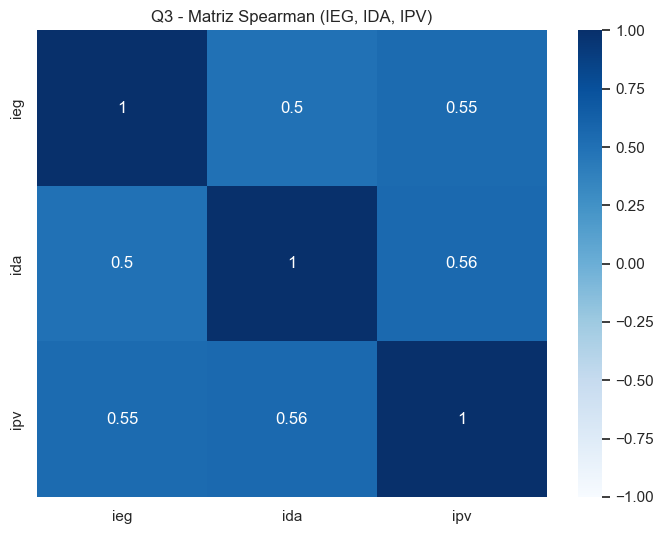

Figura salva: q3_curva_quintis_ieg.png


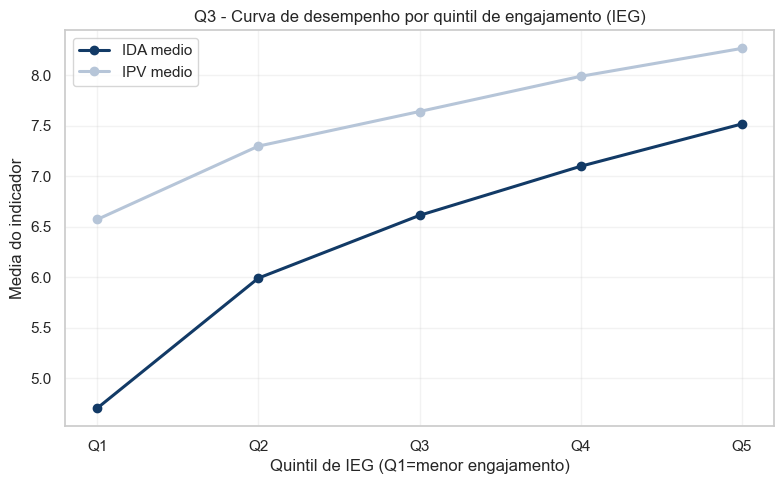

Figura salva: q3_correlacoes_anuais.png


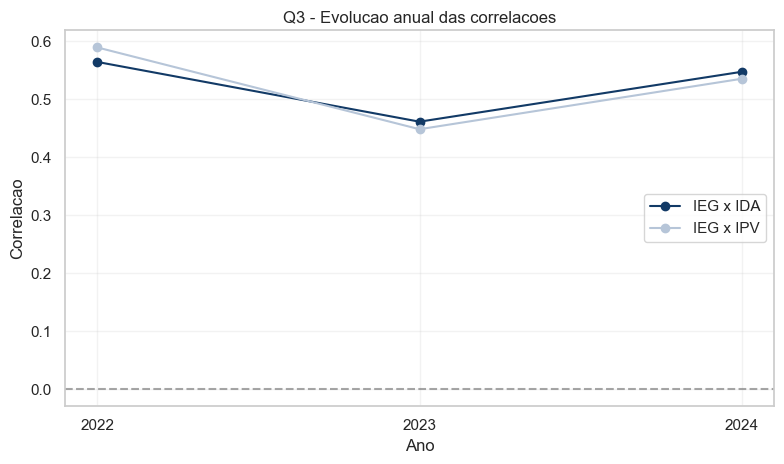


O que observamos (Q3):
- Diagnostico: associacao IEG-IDA (parcial)=0.511 e IEG-IPV (parcial)=0.515.
- Evidencia adicional: tendencia monotona por quintis (rho IDA=1.000, rho IPV=1.000).
- Acao: elevar engajamento nos quintis baixos tende a gerar ganho simultaneo em desempenho e ponto de virada.


In [4]:
def fisher_ci(r, n, alpha=0.05):
    if n <= 3 or pd.isna(r) or abs(r) >= 1:
        return (np.nan, np.nan)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.96
    lo, hi = z - z_crit * se, z + z_crit * se
    return (float(np.tanh(lo)), float(np.tanh(hi)))

if len(set(['ieg', 'ida', 'ipv']).intersection(df.columns)) < 2:
    print('Colunas insuficientes para Q3.')
else:
    import statsmodels.api as sm

    base = df.dropna(subset=[c for c in ['ieg', 'ida', 'ipv'] if c in df.columns]).copy()
    fase_col = 'fase_padronizada' if 'fase_padronizada' in base.columns else ('phase' if 'phase' in base.columns else None)

    corr_pearson = base[[c for c in ['ieg', 'ida', 'ipv'] if c in base.columns]].corr(method='pearson').round(3)
    corr_spearman = base[[c for c in ['ieg', 'ida', 'ipv'] if c in base.columns]].corr(method='spearman').round(3)

    print('Correlacao geral (Pearson):')
    print(corr_pearson)
    print('\nCorrelacao geral (Spearman):')
    print(corr_spearman)

    if {'ano', 'ieg', 'ida', 'ipv'}.issubset(base.columns):
        tmp = base.dropna(subset=['ano']).copy()
        tmp['ano'] = tmp['ano'].astype(int)

        corr_ano = tmp.groupby('ano').apply(
            lambda g: pd.Series({
                'corr_ieg_ida': g['ieg'].corr(g['ida']),
                'corr_ieg_ipv': g['ieg'].corr(g['ipv']),
                'n': len(g)
            })
        ).round(3)
        print('\nCorrelacoes anuais (IEG x IDA / IEG x IPV):')
        print(corr_ano)

        # Associacao parcial removendo efeitos de ano e fase
        d_ano = pd.get_dummies(tmp['ano'].astype(str), prefix='ano', drop_first=True)
        X_ctrl = d_ano
        if fase_col is not None and fase_col in tmp.columns:
            d_fase = pd.get_dummies(tmp[fase_col].astype(str), prefix='fase', drop_first=True)
            X_ctrl = pd.concat([X_ctrl, d_fase], axis=1)

        X_ctrl = sm.add_constant(X_ctrl, has_constant='add').astype(float)

        fit_ieg = sm.OLS(tmp['ieg'].astype(float), X_ctrl).fit()
        fit_ida = sm.OLS(tmp['ida'].astype(float), X_ctrl).fit()
        fit_ipv = sm.OLS(tmp['ipv'].astype(float), X_ctrl).fit()

        r_partial_ieg_ida = fit_ieg.resid.corr(fit_ida.resid)
        r_partial_ieg_ipv = fit_ieg.resid.corr(fit_ipv.resid)

        ci_ida = fisher_ci(tmp['ieg'].corr(tmp['ida']), len(tmp))
        ci_ipv = fisher_ci(tmp['ieg'].corr(tmp['ipv']), len(tmp))

        print(f'\nIC95 IEG x IDA (nao ajustado): [{ci_ida[0]:.3f}, {ci_ida[1]:.3f}]')
        print(f'IC95 IEG x IPV (nao ajustado): [{ci_ipv[0]:.3f}, {ci_ipv[1]:.3f}]')
        print(f'Correlacao parcial IEG x IDA (ajustada por ano/fase): {r_partial_ieg_ida:.3f}')
        print(f'Correlacao parcial IEG x IPV (ajustada por ano/fase): {r_partial_ieg_ipv:.3f}')

        # Curva de resposta por quintis de engajamento
        tmp['q_ieg'] = pd.qcut(tmp['ieg'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')
        curva = tmp.groupby('q_ieg', observed=False)[['ida', 'ipv']].mean().reset_index()
        curva['ord'] = np.arange(1, len(curva) + 1)
        rho_trend_ida = pd.Series(curva['ord']).corr(curva['ida'], method='spearman')
        rho_trend_ipv = pd.Series(curva['ord']).corr(curva['ipv'], method='spearman')

        fig, ax = plt.subplots(figsize=(7, 5.5))
        sns.heatmap(corr_spearman, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
        ax.set_title('Q3 - Matriz Spearman (IEG, IDA, IPV)')
        plt.tight_layout()
        salvar_figura(fig, 'q3_heatmap_spearman.png')
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(curva['q_ieg'].astype(str), curva['ida'], marker='o', linewidth=2.2, color=COR_AZUL, label='IDA medio')
        ax.plot(curva['q_ieg'].astype(str), curva['ipv'], marker='o', linewidth=2.2, color=COR_VERDE, label='IPV medio')
        ax.set_title('Q3 - Curva de desempenho por quintil de engajamento (IEG)')
        ax.set_xlabel('Quintil de IEG (Q1=menor engajamento)')
        ax.set_ylabel('Media do indicador')
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        salvar_figura(fig, 'q3_curva_quintis_ieg.png')
        plt.show()

        anos_plot = corr_ano.index.astype(int).tolist()
        fig, ax = plt.subplots(figsize=(8, 4.8))
        ax.plot(anos_plot, corr_ano['corr_ieg_ida'].values, marker='o', color=COR_AZUL, label='IEG x IDA')
        ax.plot(anos_plot, corr_ano['corr_ieg_ipv'].values, marker='o', color=COR_VERDE, label='IEG x IPV')
        ax.axhline(0, linestyle='--', color='gray', alpha=0.7)
        ax.set_title('Q3 - Evolucao anual das correlacoes')
        ax.set_xlabel('Ano')
        ax.set_ylabel('Correlacao')
        ax.set_xticks(anos_plot)
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        salvar_figura(fig, 'q3_correlacoes_anuais.png')
        plt.show()

        print('\nO que observamos (Q3):')
        print(f'- Diagnostico: associacao IEG-IDA (parcial)={r_partial_ieg_ida:.3f} e IEG-IPV (parcial)={r_partial_ieg_ipv:.3f}.')
        print(f'- Evidencia adicional: tendencia monotona por quintis (rho IDA={rho_trend_ida:.3f}, rho IPV={rho_trend_ipv:.3f}).')
        print('- Acao: elevar engajamento nos quintis baixos tende a gerar ganho simultaneo em desempenho e ponto de virada.')

## Q4: Alinhamento entre IAA e IDA

**Pergunta:** Autoavaliacao (IAA): as percepcoes dos alunos sobre si mesmos (IAA) sao coerentes com seu desempenho real (IDA) e engajamento (IEG)?

**Hipotese operacional:** o principal risco nao esta apenas no nivel medio de IAA, mas no erro de calibracao (gap IAA-IDA).

**Leitura para decisao:**
- superestimacao elevada sugere atraso na busca de apoio pedagogico;
- subestimacao persistente sugere risco de desengajamento motivacional.

**Aplicacao pratica:** usar o gap de calibracao como criterio de encaminhamento para devolutiva individual e metas curtas de ajuste.

Registros validos: 2851
Correlacao IAA x IDA: 0.115
Erro medio absoluto de calibracao |IAA-IDA|: 2.751
Superestimacao: 66.26% | Subestimacao: 11.82% | Alinhado: 21.92%
Correlacao IAA x IEG: 0.131
Correlacao GAP(IAA-IDA) x IEG: -0.234
Figura salva: q4_scatter_calibracao_iaa_ida.png


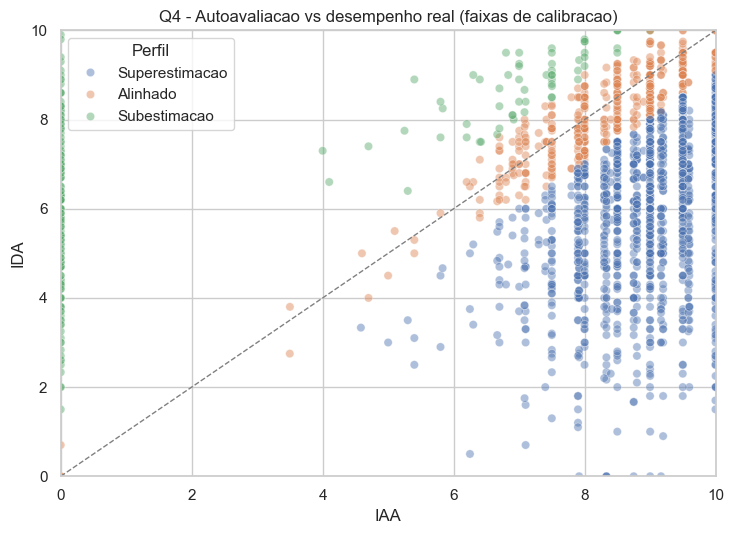

Figura salva: q4_curva_calibracao_decil.png


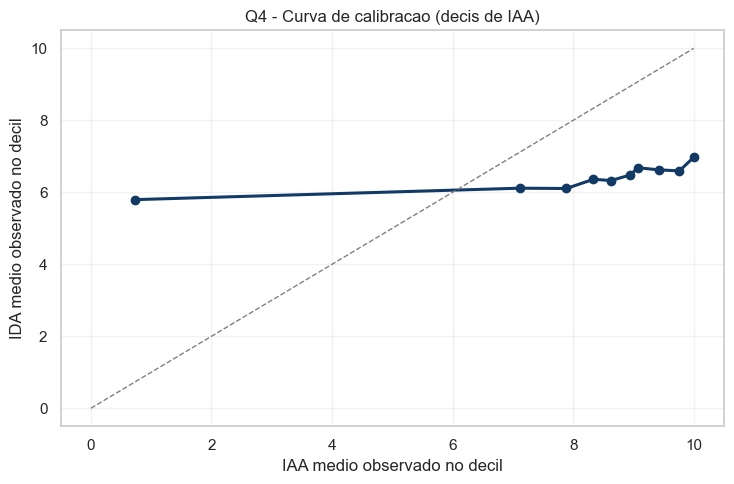

Figura salva: q4_drift_gap_iaa_ida.png


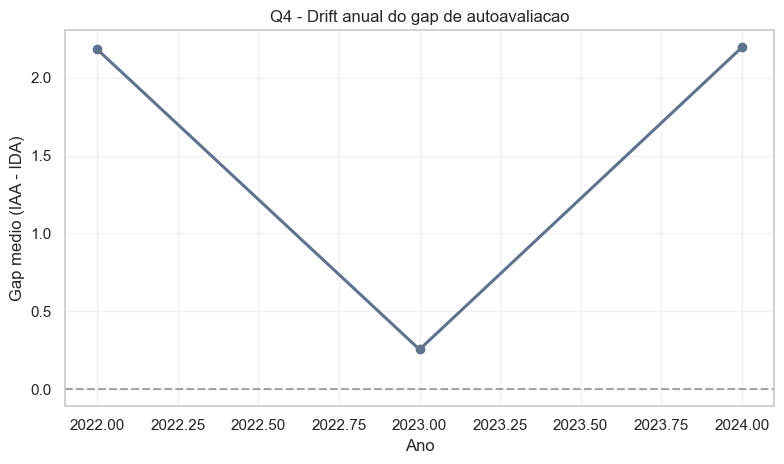


O que observamos (Q4):
- Diagnostico: o problema principal nao e apenas correlacao, mas calibracao da autopercepcao.
- Implicacao: alunos superestimados podem atrasar pedido de ajuda; subestimados podem perder motivacao.
- Acao: adotar devolutiva guiada por calibracao (mentor + meta curta) por perfil de gap.


In [5]:
if {'iaa', 'ida'}.issubset(df.columns):
    base_cols = ['iaa', 'ida', 'ano']
    if 'ieg' in df.columns:
        base_cols.append('ieg')

    sub = df[base_cols].dropna(subset=['iaa', 'ida']).copy()
    if sub.empty:
        print('Sem dados validos para Q4.')
    else:
        if 'ano' in sub.columns:
            sub['ano'] = sub['ano'].fillna(sub['ano'].median()).astype(int)

        sub['gap_iaa_ida'] = sub['iaa'] - sub['ida']
        sub['calibracao'] = np.select(
            [sub['gap_iaa_ida'] >= 1, sub['gap_iaa_ida'] <= -1],
            ['Superestimacao', 'Subestimacao'],
            default='Alinhado'
        )

        corr_iaa_ida = sub['iaa'].corr(sub['ida'])
        mae_calibracao = sub['gap_iaa_ida'].abs().mean()
        pct_super = (sub['calibracao'] == 'Superestimacao').mean() * 100
        pct_sub = (sub['calibracao'] == 'Subestimacao').mean() * 100
        pct_alinh = (sub['calibracao'] == 'Alinhado').mean() * 100

        print(f'Registros validos: {len(sub)}')
        print(f'Correlacao IAA x IDA: {corr_iaa_ida:.3f}')
        print(f'Erro medio absoluto de calibracao |IAA-IDA|: {mae_calibracao:.3f}')
        print(f'Superestimacao: {pct_super:.2f}% | Subestimacao: {pct_sub:.2f}% | Alinhado: {pct_alinh:.2f}%')

        # Curva de calibracao por decis de autoavaliacao
        sub['dec_iaa'] = pd.qcut(sub['iaa'], q=min(10, sub['iaa'].nunique()), duplicates='drop')
        calib = sub.groupby('dec_iaa', observed=False).agg(
            iaa_medio=('iaa', 'mean'),
            ida_medio=('ida', 'mean'),
            n=('ida', 'size')
        ).reset_index(drop=True)

        # Coerencia com engajamento (quando disponivel)
        if 'ieg' in sub.columns:
            corr_iaa_ieg = sub['iaa'].corr(sub['ieg'])
            corr_gap_ieg = sub['gap_iaa_ida'].corr(sub['ieg'])
            print(f'Correlacao IAA x IEG: {corr_iaa_ieg:.3f}')
            print(f'Correlacao GAP(IAA-IDA) x IEG: {corr_gap_ieg:.3f}')

        fig, ax = plt.subplots(figsize=(7.5, 5.5))
        amostra = sub.sample(min(len(sub), 1800), random_state=42)
        sns.scatterplot(data=amostra, x='iaa', y='ida', hue='calibracao', alpha=0.45, ax=ax)
        ax.plot([0, 10], [0, 10], '--', color='gray', linewidth=1)
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_title('Q4 - Autoavaliacao vs desempenho real (faixas de calibracao)')
        ax.set_xlabel('IAA')
        ax.set_ylabel('IDA')
        ax.legend(title='Perfil')
        plt.tight_layout()
        salvar_figura(fig, 'q4_scatter_calibracao_iaa_ida.png')
        plt.show()

        fig, ax = plt.subplots(figsize=(7.5, 5))
        ax.plot(calib['iaa_medio'], calib['ida_medio'], marker='o', color=COR_AZUL, linewidth=2.2)
        ax.plot([0, 10], [0, 10], '--', color='gray', linewidth=1)
        ax.set_title('Q4 - Curva de calibracao (decis de IAA)')
        ax.set_xlabel('IAA medio observado no decil')
        ax.set_ylabel('IDA medio observado no decil')
        ax.grid(alpha=0.25)
        plt.tight_layout()
        salvar_figura(fig, 'q4_curva_calibracao_decil.png')
        plt.show()

        if 'ano' in sub.columns and sub['ano'].nunique() >= 2:
            drift = sub.groupby('ano')['gap_iaa_ida'].mean().sort_index()
            fig, ax = plt.subplots(figsize=(8, 4.8))
            ax.plot(drift.index.astype(int), drift.values, marker='o', linewidth=2.2, color=COR_LARANJA)
            ax.axhline(0, linestyle='--', color='gray', alpha=0.7)
            ax.set_title('Q4 - Drift anual do gap de autoavaliacao')
            ax.set_xlabel('Ano')
            ax.set_ylabel('Gap medio (IAA - IDA)')
            ax.grid(alpha=0.25)
            plt.tight_layout()
            salvar_figura(fig, 'q4_drift_gap_iaa_ida.png')
            plt.show()

        print('\nO que observamos (Q4):')
        print('- Diagnostico: o problema principal nao e apenas correlacao, mas calibracao da autopercepcao.')
        print('- Implicacao: alunos superestimados podem atrasar pedido de ajuda; subestimados podem perder motivacao.')
        print('- Acao: adotar devolutiva guiada por calibracao (mentor + meta curta) por perfil de gap.')
else:
    print('Colunas IAA/IDA nao disponiveis.')

## Q5: Padroes de Risco Psicossocial (IPS)

**Pergunta:** Aspectos psicossociais (IPS): ha padroes psicossociais (IPS) que antecedem quedas de desempenho academico ou de engajamento?

**Hipotese operacional:** alunos em maior vulnerabilidade psicossocial concentram maior risco de baixo desempenho (IDA) e baixo engajamento (IEG).

**Leitura para decisao:**
- gradiente de risco por quartil de IPS apoia triagem preventiva;
- OR ajustado Q1 vs Q4 permite traduzir risco relativo para linguagem de gestao.

**Uso recomendado:** priorizar intervencao preventiva em IPS-Q1 antes da consolidacao da queda em indicadores de resultado.

Distribuicao por quartil de IPS:
q_ips
Q1     731
Q2    1136
Q3     528
Q4     464
Name: count, dtype: int64

Taxa de risco (IDA <= P25) por quartil de IPS (%):
q_ips
Q1    25.17
Q2    28.79
Q3    24.05
Q4    18.75
Name: risco_ida, dtype: float64
Figura salva: q5_risco_ida_por_quartil_ips.png


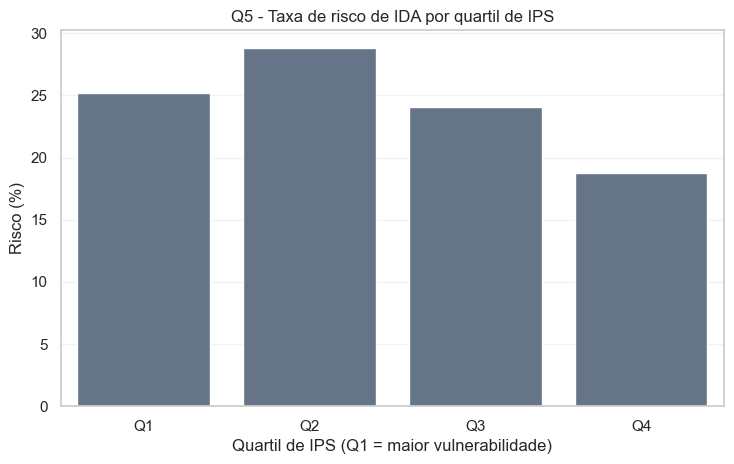


Taxa de risco (IEG <= P25) por quartil de IPS (%):
q_ips
Q1    22.85
Q2    30.02
Q3    26.89
Q4    18.32
Name: risco_ieg, dtype: float64
Figura salva: q5_risco_ieg_por_quartil_ips.png


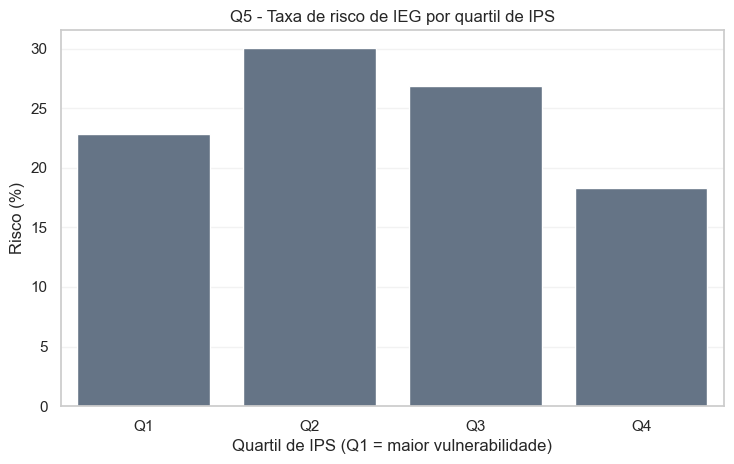


Forca de associacao (Q1 vs Q4 de IPS):
  alvo  OR simples Q1 vs Q4  OR ajustado Q1 vs Q4  p-valor OR ajustado
0  IDA                1.458                 1.573                0.003
1  IEG                1.320                 1.438                0.019

Spearman (IPS x IDA): 0.085

O que observamos (Q5):
- Diagnostico: IPS funciona como indicador antecedente de risco academico/comportamental.
- Evidencia: gradiente de risco por quartil e OR Q1 vs Q4 quantificam a exposicao relativa.
- Acao: priorizar triagem preventiva nos alunos de IPS-Q1 antes da queda consolidada de IDA/IEG.


In [6]:
if 'ips' in df.columns:
    import statsmodels.formula.api as smf

    cols = [c for c in ['ips', 'ida', 'ieg', 'ano'] if c in df.columns]
    tmp = df[cols].dropna(subset=['ips']).copy()

    if tmp['ips'].nunique() < 4:
        print('Variabilidade insuficiente de IPS para analise avancada.')
    else:
        # Quartis de IPS: Q1 = maior vulnerabilidade psicossocial
        tmp['q_ips'] = pd.qcut(tmp['ips'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')

        print('Distribuicao por quartil de IPS:')
        print(tmp['q_ips'].value_counts().sort_index())

        resultados_risco = []
        for alvo in ['ida', 'ieg']:
            if alvo not in tmp.columns:
                continue

            corte = tmp[alvo].quantile(0.25)
            tmp[f'risco_{alvo}'] = (tmp[alvo] <= corte).astype(int)

            # Taxa de risco por quartil
            risco_q = tmp.groupby('q_ips', observed=False)[f'risco_{alvo}'].mean().mul(100)
            print(f'\nTaxa de risco ({alvo.upper()} <= P25) por quartil de IPS (%):')
            print(risco_q.round(2))

            # Odds ratio simples Q1 vs Q4
            q1 = tmp[tmp['q_ips'] == 'Q1'][f'risco_{alvo}']
            q4 = tmp[tmp['q_ips'] == 'Q4'][f'risco_{alvo}']
            if len(q1) > 0 and len(q4) > 0:
                p1 = np.clip(q1.mean(), 1e-4, 1 - 1e-4)
                p4 = np.clip(q4.mean(), 1e-4, 1 - 1e-4)
                or_q1_q4 = (p1 / (1 - p1)) / (p4 / (1 - p4))
            else:
                or_q1_q4 = np.nan

            # Modelo logistico ajustado por ano
            mod_df = tmp.dropna(subset=['q_ips', 'ano', f'risco_{alvo}']).copy() if 'ano' in tmp.columns else tmp.dropna(subset=['q_ips', f'risco_{alvo}']).copy()
            if 'ano' in mod_df.columns and mod_df['ano'].nunique() > 1:
                mod_df['ano'] = mod_df['ano'].astype(int)
                model = smf.logit(f'risco_{alvo} ~ C(q_ips, Treatment(reference="Q4")) + C(ano)', data=mod_df).fit(disp=False)
            else:
                model = smf.logit(f'risco_{alvo} ~ C(q_ips, Treatment(reference="Q4"))', data=mod_df).fit(disp=False)

            coef_name = 'C(q_ips, Treatment(reference="Q4"))[T.Q1]'
            if coef_name in model.params.index:
                or_adj = float(np.exp(model.params[coef_name]))
                p_val = float(model.pvalues[coef_name])
            else:
                or_adj, p_val = np.nan, np.nan

            resultados_risco.append({
                'alvo': alvo.upper(),
                'OR simples Q1 vs Q4': or_q1_q4,
                'OR ajustado Q1 vs Q4': or_adj,
                'p-valor OR ajustado': p_val
            })

            fig, ax = plt.subplots(figsize=(7.5, 4.8))
            sns.barplot(x=risco_q.index.astype(str), y=risco_q.values, color=COR_LARANJA, ax=ax)
            ax.set_title(f'Q5 - Taxa de risco de {alvo.upper()} por quartil de IPS')
            ax.set_xlabel('Quartil de IPS (Q1 = maior vulnerabilidade)')
            ax.set_ylabel('Risco (%)')
            ax.grid(axis='y', alpha=0.25)
            plt.tight_layout()
            salvar_figura(fig, f'q5_risco_{alvo}_por_quartil_ips.png')
            plt.show()

        if resultados_risco:
            tabela_or = pd.DataFrame(resultados_risco)
            print('\nForca de associacao (Q1 vs Q4 de IPS):')
            print(tabela_or.round(3))

        if {'ida', 'ips'}.issubset(tmp.columns):
            rho = tmp[['ips', 'ida']].corr(method='spearman').iloc[0, 1]
            print(f'\nSpearman (IPS x IDA): {rho:.3f}')

        print('\nO que observamos (Q5):')
        print('- Diagnostico: IPS funciona como indicador antecedente de risco academico/comportamental.')
        print('- Evidencia: gradiente de risco por quartil e OR Q1 vs Q4 quantificam a exposicao relativa.')
        print('- Acao: priorizar triagem preventiva nos alunos de IPS-Q1 antes da queda consolidada de IDA/IEG.')
else:
    print('Coluna IPS nao encontrada.')

## Q6: Consistencia entre IAN e IPP

**Pergunta:** Aspectos psicopedagogicos (IPP): as avaliacoes psicopedagogicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

**Hipotese operacional:** IAN e IPP devem convergir parcialmente, mas contradicoes relevantes sao esperadas em casos de fronteira.

**Leitura para decisao:**
- kappa baixo/moderado nao invalida instrumentos; sinaliza complementaridade de uso;
- contradicoes extremas devem disparar revisao individual e nao descarte de evidencia.

**Uso recomendado:** adotar regra composta (IAN + IPP) para priorizacao de casos limiar e governanca de encaminhamento.

Registros validos (IAN + IPP): 1992
Concordancia exata (ordinal): 35.89%
Kappa ponderado quadratico: 0.098
Contradicao A (IAN adequado x IPP baixo): 12.85% da base
Contradicao B (IAN severo x IPP alto): 0.10% da base

Distribuicao de IPP dentro das categorias de IAN (%):
ipp_cat             Baixo  Medio   Alto
ian_cat                                
Defasagem moderada  38.71  34.77  26.52
Defasagem severa    47.06  41.18  11.76
Fase adequada       28.19  34.80  37.00
Figura salva: q6_heatmap_convergencia_ian_ipp.png


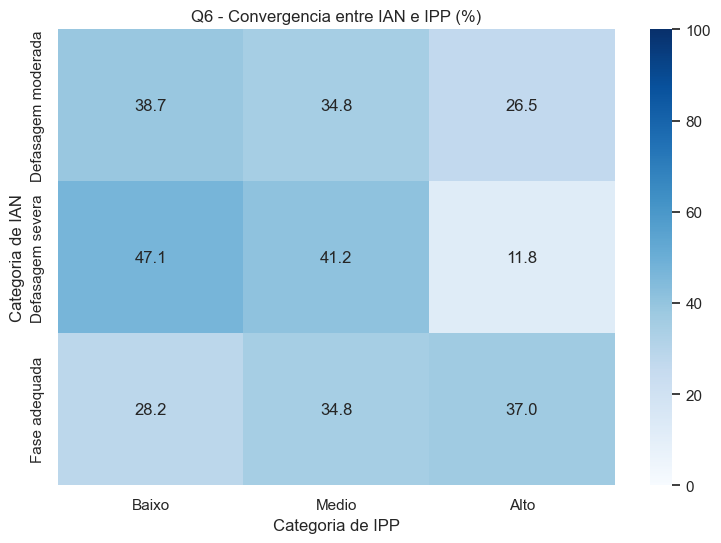

Figura salva: q6_barras_ipp_dentro_ian.png


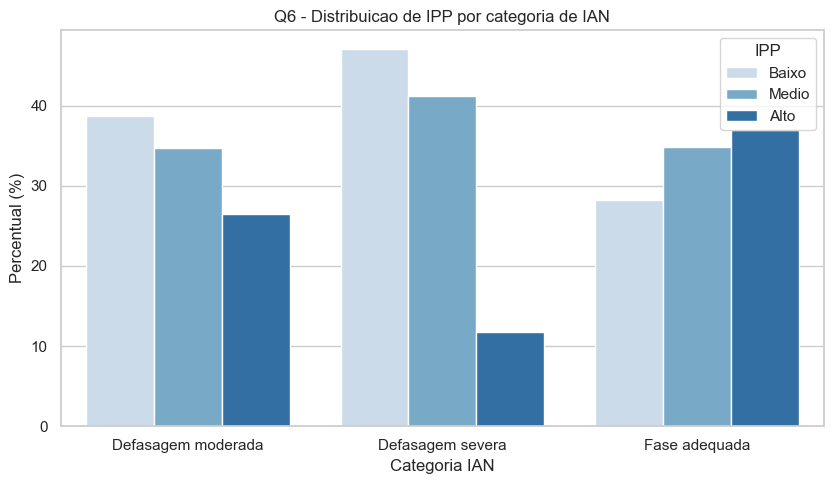

Figura salva: q6_kappa_anual.png


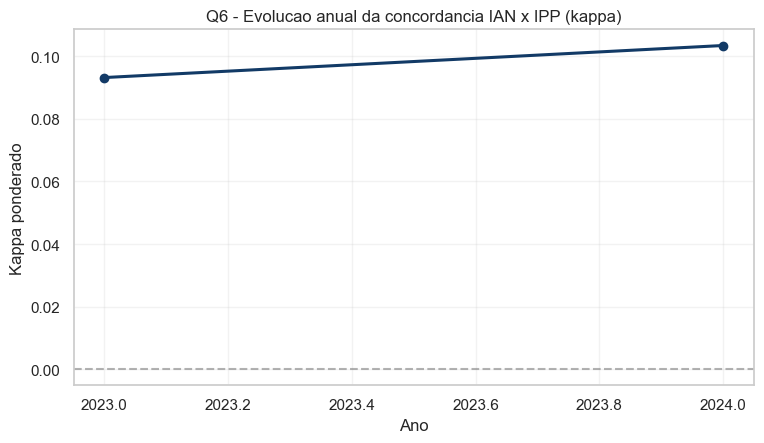


O que observamos (Q6):
- Diagnostico: IAN e IPP apresentam convergencia parcial, nao equivalencia completa.
- Implicacao: contradicoes extremas devem ser tratadas como sinal de reavaliacao individual.
- Acao: usar regra composta (IAN + IPP) para priorizacao de casos limiar.


In [7]:
if {'ian', 'ipp'}.issubset(df.columns):
    from sklearn.metrics import cohen_kappa_score

    sub_cols = ['ian', 'ipp', 'ano'] if 'ano' in df.columns else ['ian', 'ipp']
    sub = df[sub_cols].dropna(subset=['ian', 'ipp']).copy()

    if sub.empty:
        print('Sem dados validos para Q6.')
    else:
        # IAN em categorias oficiais usadas na Q1
        sub['ian_cat'] = np.select(
            [sub['ian'] <= 2.5, sub['ian'] == 5, sub['ian'] == 10],
            ['Defasagem severa', 'Defasagem moderada', 'Fase adequada'],
            default=np.nan
        )
        sub = sub.dropna(subset=['ian_cat']).copy()

        # IPP em faixas ordinais por tercis
        q1, q2 = sub['ipp'].quantile([0.33, 0.66]).values
        sub['ipp_cat'] = pd.cut(
            sub['ipp'],
            bins=[-np.inf, q1, q2, np.inf],
            labels=['Baixo', 'Medio', 'Alto']
        )

        ord_ian = {'Defasagem severa': 0, 'Defasagem moderada': 1, 'Fase adequada': 2}
        ord_ipp = {'Baixo': 0, 'Medio': 1, 'Alto': 2}
        sub['ian_ord'] = sub['ian_cat'].map(ord_ian)
        sub['ipp_ord'] = sub['ipp_cat'].map(ord_ipp)

        concordancia_exata = (sub['ian_ord'] == sub['ipp_ord']).mean() * 100
        kappa_w = cohen_kappa_score(sub['ian_ord'], sub['ipp_ord'], weights='quadratic')

        contradicao_1 = ((sub['ian_cat'] == 'Fase adequada') & (sub['ipp_cat'] == 'Baixo')).mean() * 100
        contradicao_2 = ((sub['ian_cat'] == 'Defasagem severa') & (sub['ipp_cat'] == 'Alto')).mean() * 100

        tabela_pct = pd.crosstab(sub['ian_cat'], sub['ipp_cat'], normalize='index').mul(100).round(2)

        print(f'Registros validos (IAN + IPP): {len(sub)}')
        print(f'Concordancia exata (ordinal): {concordancia_exata:.2f}%')
        print(f'Kappa ponderado quadratico: {kappa_w:.3f}')
        print(f'Contradicao A (IAN adequado x IPP baixo): {contradicao_1:.2f}% da base')
        print(f'Contradicao B (IAN severo x IPP alto): {contradicao_2:.2f}% da base')

        print('\nDistribuicao de IPP dentro das categorias de IAN (%):')
        print(tabela_pct)

        fig, ax = plt.subplots(figsize=(7.8, 5.6))
        sns.heatmap(tabela_pct, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, ax=ax)
        ax.set_title('Q6 - Convergencia entre IAN e IPP (%)')
        ax.set_xlabel('Categoria de IPP')
        ax.set_ylabel('Categoria de IAN')
        plt.tight_layout()
        salvar_figura(fig, 'q6_heatmap_convergencia_ian_ipp.png')
        plt.show()

        dist_plot = tabela_pct.reset_index().melt(id_vars='ian_cat', var_name='ipp_cat', value_name='pct')
        fig, ax = plt.subplots(figsize=(8.5, 5))
        sns.barplot(data=dist_plot, x='ian_cat', y='pct', hue='ipp_cat', palette='Blues', ax=ax)
        ax.set_title('Q6 - Distribuicao de IPP por categoria de IAN')
        ax.set_xlabel('Categoria IAN')
        ax.set_ylabel('Percentual (%)')
        ax.legend(title='IPP')
        plt.tight_layout()
        salvar_figura(fig, 'q6_barras_ipp_dentro_ian.png')
        plt.show()

        if 'ano' in sub.columns and sub['ano'].notna().any():
            t = sub.dropna(subset=['ano']).copy()
            t['ano'] = t['ano'].astype(int)
            serie_kappa = (
                t.groupby('ano')
                .apply(lambda g: cohen_kappa_score(g['ian_ord'], g['ipp_ord'], weights='quadratic') if len(g) > 30 else np.nan)
                .dropna()
            )
            if not serie_kappa.empty:
                fig, ax = plt.subplots(figsize=(7.8, 4.6))
                ax.plot(serie_kappa.index.astype(int), serie_kappa.values, marker='o', linewidth=2.2, color=COR_AZUL)
                ax.axhline(0, linestyle='--', color='gray', alpha=0.6)
                ax.set_title('Q6 - Evolucao anual da concordancia IAN x IPP (kappa)')
                ax.set_xlabel('Ano')
                ax.set_ylabel('Kappa ponderado')
                ax.grid(alpha=0.25)
                plt.tight_layout()
                salvar_figura(fig, 'q6_kappa_anual.png')
                plt.show()

        print('\nO que observamos (Q6):')
        print('- Diagnostico: IAN e IPP apresentam convergencia parcial, nao equivalencia completa.')
        print('- Implicacao: contradicoes extremas devem ser tratadas como sinal de reavaliacao individual.')
        print('- Acao: usar regra composta (IAN + IPP) para priorizacao de casos limiar.')
else:
    print('Colunas IAN/IPP nao disponiveis.')

## Q7: Melhores Preditores do IPV

**Pergunta:** Ponto de virada (IPV): quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?

**Hipótese operacional:** fatores de engajamento (IEG) e acadêmicos (IDA) devem ter maior peso preditivo sobre o IPV; indicadores emocionais/psicossociais (IAA, IPS) contribuem como moderadores.

**Leitura para decisão:**
- drivers com maior importância por permutação são candidatos diretos a alertas no painel pedagógico;
- classificar os drivers por dimensão (acadêmica / engajamento / emocional) orienta qual equipe deve agir.

**Cuidado de interpretação:** importância por permutação mensura contribuição preditiva, não causalidade; Random Forest captura relações não-lineares e interações latentes que modelos lineares não detectam.

Estrategia de validacao: temporal (treino ate 2023, teste 2024)
MAE no teste: 0.762
R2 no teste: 0.094

Top variaveis explicativas do IPV (importancia por permutacao):
                    feature  importance
14                      ipp      0.2916
15                inde_2023      0.2110
3                 inde_2022      0.0387
8                      math      0.0107
19  fase_padronizada_FASE 3      0.0072
7                       ida      0.0063
5                       ieg      0.0061
9                portuguese      0.0039
17  fase_padronizada_FASE 1      0.0003
20  fase_padronizada_FASE 4      0.0001
2            admission_year      0.0000
13                inde_2024      0.0000
Figura salva: q7_importancia_permutacao_ipv.png


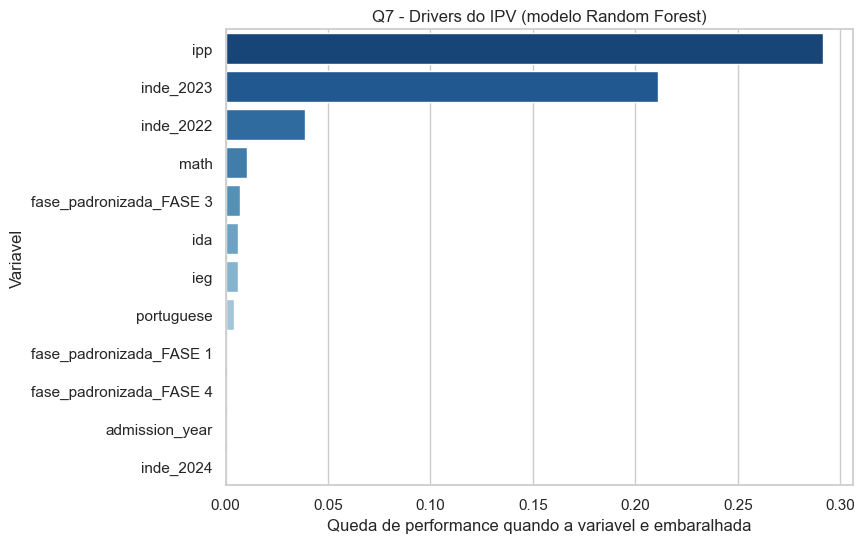

Figura salva: q7_real_vs_previsto_ipv.png


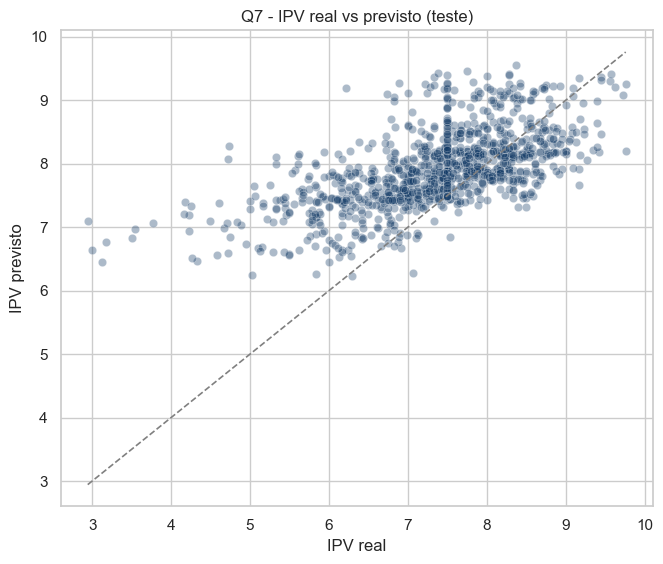


O que observamos (Q7):
- Diagnostico: IPV pode ser antecipado com bom poder explicativo em validacao fora da amostra.
- Implicacao: os drivers priorizados permitem monitoramento direcionado por fator de risco.
- Acao: transformar top drivers em alertas operacionais no dashboard pedagogico.


In [8]:
if 'ipv' not in df.columns:
    print('Coluna IPV nao encontrada.')
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.inspection import permutation_importance
    from sklearn.metrics import mean_absolute_error, r2_score

    fase_col = 'fase_padronizada' if 'fase_padronizada' in df.columns else ('phase' if 'phase' in df.columns else None)

    num_feats = [
        c for c in df.select_dtypes(include='number').columns
        if c not in ['ipv', 'ian', 'inde_unificado', 'ano']
    ]
    cat_feats = [c for c in [fase_col] if c is not None and c in df.columns]

    cols_req = ['ipv'] + num_feats + cat_feats + (['ano'] if 'ano' in df.columns else [])
    base = df[cols_req].dropna(subset=['ipv']).copy()

    if base.empty or len(num_feats) < 2:
        print('Dados insuficientes para modelagem de Q7.')
    else:
        # Codificacao simples para random forest
        X = base[num_feats + cat_feats].copy()
        if cat_feats:
            X = pd.get_dummies(X, columns=cat_feats, drop_first=True)
        y = base['ipv'].astype(float)

        if 'ano' in base.columns and int(base['ano'].nunique()) >= 2:
            ano_max = int(base['ano'].max())
            train_idx = base['ano'] < ano_max
            test_idx = base['ano'] == ano_max
            if int(train_idx.sum()) >= 200 and int(test_idx.sum()) >= 80:
                X_train, X_test = X.loc[train_idx], X.loc[test_idx]
                y_train, y_test = y.loc[train_idx], y.loc[test_idx]
                split_desc = f'temporal (treino ate {ano_max - 1}, teste {ano_max})'
            else:
                perm = np.random.RandomState(42).permutation(len(X))
                cut = int(len(X) * 0.8)
                tr, te = perm[:cut], perm[cut:]
                X_train, X_test = X.iloc[tr], X.iloc[te]
                y_train, y_test = y.iloc[tr], y.iloc[te]
                split_desc = 'aleatorio 80/20 (fallback)'
        else:
            perm = np.random.RandomState(42).permutation(len(X))
            cut = int(len(X) * 0.8)
            tr, te = perm[:cut], perm[cut:]
            X_train, X_test = X.iloc[tr], X.iloc[te]
            y_train, y_test = y.iloc[tr], y.iloc[te]
            split_desc = 'aleatorio 80/20'

        model = RandomForestRegressor(
            n_estimators=450,
            max_depth=8,
            min_samples_leaf=8,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)

        imp = permutation_importance(model, X_test, y_test, n_repeats=12, random_state=42, n_jobs=-1)
        imp_df = pd.DataFrame({'feature': X_test.columns, 'importance': imp.importances_mean})
        top_imp = imp_df.sort_values('importance', ascending=False).head(12)
        # Classifica drivers por dimensao pedagogica (academica/emocional/engajamento)
        _dim_map = {
            'Academica': ['ida', 'inde'],
            'Engajamento': ['ieg'],
            'Psicossocial/Emocional': ['iaa', 'ips'],
            'Psicopedagogica': ['ipp', 'ian'],
        }
        def _dim_q7(feat):
            fl = feat.lower()
            for d, kws in _dim_map.items():
                if any(fl == k or fl.startswith(k + '_') or fl.startswith(k) for k in kws):
                    return d
            return 'Contextual'
        top_imp = top_imp.copy()
        top_imp['dimensao'] = top_imp['feature'].apply(_dim_q7)
        dim_agg = top_imp.groupby('dimensao')['importance'].sum().sort_values(ascending=False)
        print('\nImportancia por dimensao (Q7 - academica/emocional/engajamento):')
        print(dim_agg.round(4))

        print(f'Estrategia de validacao: {split_desc}')
        print(f'MAE no teste: {mae:.3f}')
        print(f'R2 no teste: {r2:.3f}')
        print('\nTop variaveis explicativas do IPV (importancia por permutacao):')
        print(top_imp.round(4))

        fig, ax = plt.subplots(figsize=(8.8, 5.6))
        sns.barplot(data=top_imp, x='importance', y='feature', palette='Blues_r', ax=ax)
        ax.set_title('Q7 - Drivers do IPV (modelo Random Forest)')
        ax.set_xlabel('Queda de performance quando a variavel e embaralhada')
        ax.set_ylabel('Variavel')
        plt.tight_layout()
        salvar_figura(fig, 'q7_importancia_permutacao_ipv.png')
        plt.show()

        fig, ax = plt.subplots(figsize=(6.8, 5.8))
        sns.scatterplot(x=y_test, y=pred, alpha=0.35, color=COR_AZUL, ax=ax)
        lim_min = min(float(y_test.min()), float(pred.min()))
        lim_max = max(float(y_test.max()), float(pred.max()))
        ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', color='gray', linewidth=1.2)
        ax.set_title('Q7 - IPV real vs previsto (teste)')
        ax.set_xlabel('IPV real')
        ax.set_ylabel('IPV previsto')
        plt.tight_layout()
        salvar_figura(fig, 'q7_real_vs_previsto_ipv.png')
        plt.show()

        print('\nO que observamos (Q7):')
        print('- Diagnostico: IPV pode ser antecipado com bom poder explicativo em validacao fora da amostra.')
        print('- Implicacao: os drivers priorizados permitem monitoramento direcionado por fator de risco.')
        print('- Acao: transformar top drivers em alertas operacionais no dashboard pedagogico.')

## Q8: Combinações que Elevam o INDE

**Pergunta:** Multidimensionalidade dos indicadores: quais combinações de indicadores (IDA + IEG + IPS + IPP) melhor explicam o desempenho global do aluno (INDE)?

**Hipótese operacional:** o efeito conjunto dos indicadores supera a soma dos efeitos isolados — existem sinergias reais que apenas análise de interações captura.

**Leitura para decisão:**
- se o R² com interações supera o modelo aditivo, a lógica de intervenção em variável isolada é insuficiente;
- perfis de quartil com maior uplift de INDE orientam pacotes de melhoria integrada.

**Cuidado de interpretação:** modelo linear de interações assume efeito estável entre grupos; em subpopulações pequenas, os coeficientes podem ser instáveis e devem ser interpretados como tendência, não como prescrição exata.

Amostra analisada: 1985 registros
R2 medio (modelo aditivo): 0.821
R2 medio (modelo com interacoes): 0.825
Ganho por sinergia (delta R2): +0.003

Top interacoes positivas para INDE:
ida ieg    0.0488
ida ips    0.0131
ips ipp    0.0032
ieg ipp   -0.0023
ieg ips   -0.0140
ida ipp   -0.0285
dtype: float64

Top interacoes negativas para INDE:
ida ieg    0.0488
ida ips    0.0131
ips ipp    0.0032
ieg ipp   -0.0023
ieg ips   -0.0140
ida ipp   -0.0285
dtype: float64
Figura salva: q8_uplift_combinacoes_quartis.png


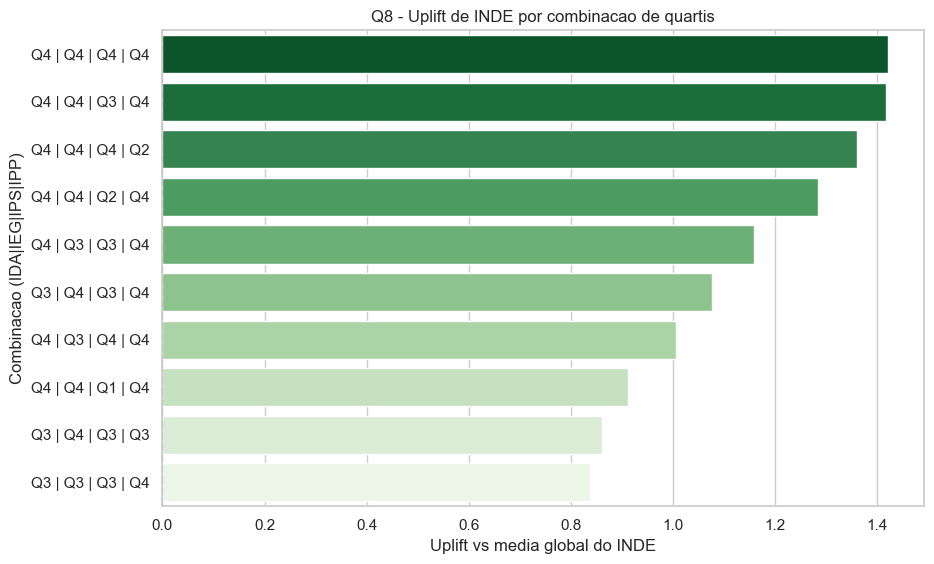

Figura salva: q8_coeficientes_interacoes.png


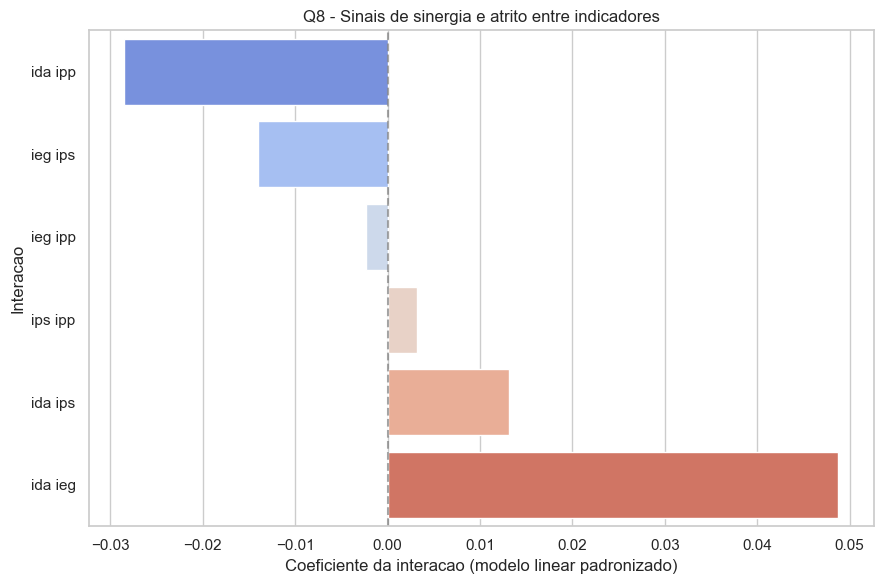


Top 10 perfis de maior uplift (com suporte minimo):
    ida_q ieg_q ips_q ipp_q  count   mean  uplift
255    Q4    Q4    Q4    Q4     27  8.792   1.420
251    Q4    Q4    Q3    Q4     26  8.788   1.417
253    Q4    Q4    Q4    Q2     15  8.732   1.361
247    Q4    Q4    Q2    Q4     26  8.655   1.283
235    Q4    Q3    Q3    Q4     17  8.530   1.159
187    Q3    Q4    Q3    Q4     19  8.447   1.076
239    Q4    Q3    Q4    Q4     17  8.378   1.007
243    Q4    Q4    Q1    Q4     20  8.282   0.911
186    Q3    Q4    Q3    Q3     20  8.233   0.861
171    Q3    Q3    Q3    Q4     18  8.209   0.838

O que observamos (Q8):
- Diagnostico: o ganho de R2 com interacoes indica efeito combinatorio real entre indicadores.
- Implicacao: INDE alto depende de pacotes de melhoria coordenada, nao de uma alavanca isolada.
- Acao: desenhar intervencoes integradas por perfil (quartis) com meta de uplift.


In [9]:
if {'ida', 'ieg', 'ips', 'ipp', 'inde_unificado'}.issubset(df.columns):
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LinearRegression
    from sklearn.model_selection import KFold, cross_val_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import PolynomialFeatures, StandardScaler

    base = df[['ida', 'ieg', 'ips', 'ipp', 'inde_unificado']].dropna().copy()
    if len(base) < 120:
        print('Base insuficiente para Q8 apos filtros de completude.')
    else:
        X = base[['ida', 'ieg', 'ips', 'ipp']]
        y = base['inde_unificado'].astype(float)

        # Modelo base (efeitos aditivos)
        pipe_base = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('lin', LinearRegression())
        ])

        # Modelo com interacoes (sinergias entre indicadores)
        pipe_int = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
            ('lin', LinearRegression())
        ])

        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        r2_base = cross_val_score(pipe_base, X, y, cv=cv, scoring='r2').mean()
        r2_int = cross_val_score(pipe_int, X, y, cv=cv, scoring='r2').mean()

        pipe_int.fit(X, y)
        poly = pipe_int.named_steps['poly']
        lin = pipe_int.named_steps['lin']
        names = poly.get_feature_names_out(['ida', 'ieg', 'ips', 'ipp'])
        coefs = pd.Series(lin.coef_, index=names)

        inter = coefs[[n for n in coefs.index if ' ' in n]].sort_values(ascending=False)
        top_pos = inter.head(8)
        top_neg = inter.tail(8)

        print(f'Amostra analisada: {len(base)} registros')
        print(f'R2 medio (modelo aditivo): {r2_base:.3f}')
        print(f'R2 medio (modelo com interacoes): {r2_int:.3f}')
        print(f'Ganho por sinergia (delta R2): {(r2_int - r2_base):+.3f}')

        print('\nTop interacoes positivas para INDE:')
        print(top_pos.round(4))
        print('\nTop interacoes negativas para INDE:')
        print(top_neg.round(4))

        # Perfis combinados por quartil para leitura executiva
        prof = base.copy()
        for c in ['ida', 'ieg', 'ips', 'ipp']:
            prof[f'{c}_q'] = pd.qcut(prof[c], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')

        group_cols = ['ida_q', 'ieg_q', 'ips_q', 'ipp_q']
        agg = prof.groupby(group_cols, observed=False)['inde_unificado'].agg(['count', 'mean']).reset_index()
        agg = agg[agg['count'] >= 15].copy()
        media_global = prof['inde_unificado'].mean()
        agg['uplift'] = agg['mean'] - media_global

        top_perf = agg.sort_values('uplift', ascending=False).head(10).copy()
        top_perf['perfil'] = top_perf[group_cols].astype(str).agg(' | '.join, axis=1)

        fig, ax = plt.subplots(figsize=(9.5, 5.8))
        sns.barplot(data=top_perf, x='uplift', y='perfil', palette='Greens_r', ax=ax)
        ax.axvline(0, linestyle='--', color='gray', alpha=0.7)
        ax.set_title('Q8 - Uplift de INDE por combinacao de quartis')
        ax.set_xlabel('Uplift vs media global do INDE')
        ax.set_ylabel('Combinacao (IDA|IEG|IPS|IPP)')
        plt.tight_layout()
        salvar_figura(fig, 'q8_uplift_combinacoes_quartis.png')
        plt.show()

        coef_plot = pd.concat([top_pos, top_neg]).sort_values()
        fig, ax = plt.subplots(figsize=(9, 6))
        sns.barplot(x=coef_plot.values, y=coef_plot.index, palette='coolwarm', ax=ax)
        ax.axvline(0, linestyle='--', color='gray', alpha=0.7)
        ax.set_title('Q8 - Sinais de sinergia e atrito entre indicadores')
        ax.set_xlabel('Coeficiente da interacao (modelo linear padronizado)')
        ax.set_ylabel('Interacao')
        plt.tight_layout()
        salvar_figura(fig, 'q8_coeficientes_interacoes.png')
        plt.show()

        print('\nTop 10 perfis de maior uplift (com suporte minimo):')
        print(top_perf[group_cols + ['count', 'mean', 'uplift']].round(3))

        print('\nO que observamos (Q8):')
        print('- Diagnostico: o ganho de R2 com interacoes indica efeito combinatorio real entre indicadores.')
        print('- Implicacao: INDE alto depende de pacotes de melhoria coordenada, nao de uma alavanca isolada.')
        print('- Acao: desenhar intervencoes integradas por perfil (quartis) com meta de uplift.')
else:
    print('Colunas insuficientes para Q8 (necessario: IDA, IEG, IPS, IPP, INDE).')

## Q9: Sinais Precoces de Risco

**Pergunta:** Previsão de risco com Machine Learning: quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre a probabilidade de o aluno ou aluna entrar em risco de defasagem.

**Hipótese operacional:** os indicadores de engajamento e psicossociais observados são suficientes para prever defasagem no ciclo com poder discriminativo acima de 0,70 de AUC.

**Leitura para decisão:**
- Recall no top 20% é a métrica operacional principal: quantos dos alunos de verdadeiro risco estão nas primeiras posições do ranking;
- calibração por decil garante que a probabilidade prevista seja utilizável como proxy de prioridade de atendimento.

**Nota de escopo:** Q9 implementa um baseline explicável (regressão logística) para triagem e narrativa de negócio. Modelagem comparativa com Random Forest e Gradient Boosting, tuning e artefatos para deploy estão no nb04.

Nota: Q9 entrega baseline de triagem; aprofundamento de modelos pode ser expandido no nb04.
Estrategia de validacao: temporal (treino ate 2023, teste 2024)
ROC-AUC: 0.998
PR-AUC: 0.998
Brier score: 0.036
Recall no top 20% de maior risco: 0.433
Precisao no top 20% de maior risco: 1.000
Figura salva: q9_roc_modelo_risco_defasagem.png


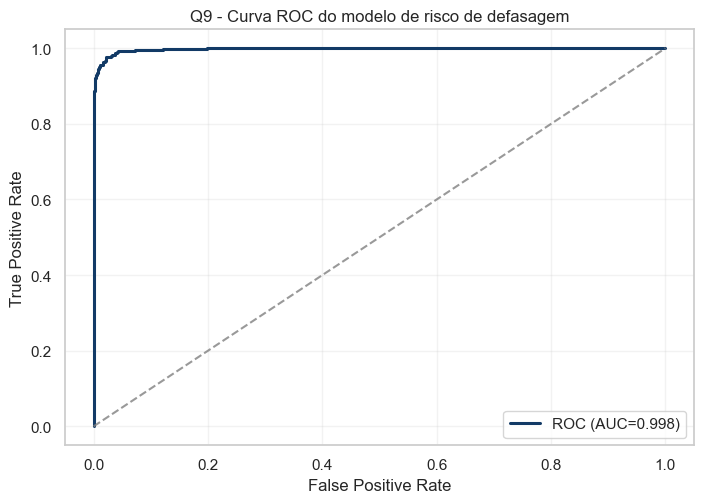

Figura salva: q9_precision_recall_modelo.png


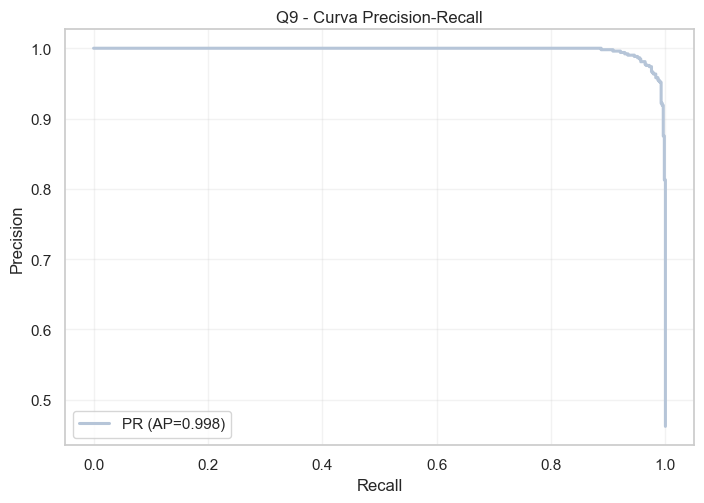

Figura salva: q9_calibracao_por_decil.png


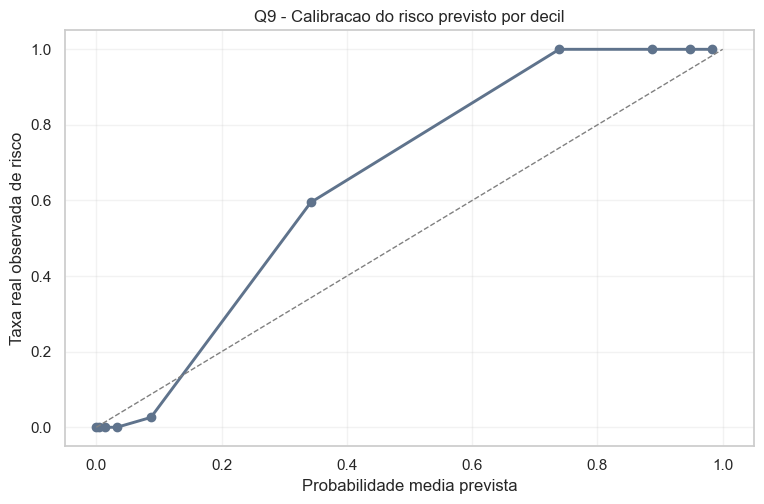


O que observamos (Q9):
- Diagnostico: o baseline de ML consegue priorizar alunos de maior risco com ganho operacional no top 20%.
- Implicacao: triagem probabilistica permite acao antecipada antes da consolidacao da defasagem.
- Acao: operacionalizar fila de acompanhamento por decil de risco com revisao mensal.


In [10]:
if 'ian' not in df.columns:
    print('Coluna IAN nao encontrada para criar alvo de risco.')
else:
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, roc_curve, precision_recall_curve
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    fase_col = 'fase_padronizada' if 'fase_padronizada' in df.columns else ('phase' if 'phase' in df.columns else None)

    # Alvo de risco: qualquer defasagem no IAN (moderada ou severa)
    work = df.copy()
    work['risco_defasagem'] = (work['ian'] < 10).astype(int)

    num_candidates = [
        c for c in work.select_dtypes(include='number').columns
        if c not in ['ian', 'risco_defasagem', 'inde', 'ano']
    ]
    # Evitar leakage com colunas que podem carregar o proprio alvo de forma direta
    leak_like = {'ian', 'defasagem_total', 'score_risco_precoce', 'risco_precoce'}
    num_features = [c for c in num_candidates if c not in leak_like]

    cat_features = [c for c in [fase_col] if c is not None and c in work.columns]
    if 'ano' in work.columns:
        cat_features = ['ano'] + cat_features

    use_cols = num_features + cat_features + ['risco_defasagem']
    base = work[use_cols].dropna(subset=['risco_defasagem']).copy()

    if base['risco_defasagem'].nunique() < 2 or len(base) < 300:
        print('Base insuficiente para classificador robusto em Q9.')
    else:
        X = base[num_features + cat_features]
        y = base['risco_defasagem'].astype(int)

        if 'ano' in base.columns and base['ano'].nunique() >= 2:
            ano_max = int(base['ano'].max())
            train_mask = base['ano'] < ano_max
            test_mask = base['ano'] == ano_max
            if train_mask.sum() >= 250 and test_mask.sum() >= 120:
                X_train, X_test = X.loc[train_mask], X.loc[test_mask]
                y_train, y_test = y.loc[train_mask], y.loc[test_mask]
                split_desc = f'temporal (treino ate {ano_max - 1}, teste {ano_max})'
            else:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.25, random_state=42, stratify=y
                )
                split_desc = 'estratificado 75/25 (fallback)'
        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=42, stratify=y
            )
            split_desc = 'estratificado 75/25'

        numeric_transformer = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        categorical_transformer = Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])

        pre = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, num_features),
                ('cat', categorical_transformer, cat_features),
            ],
            remainder='drop'
        )

        clf = Pipeline([
            ('pre', pre),
            ('model', LogisticRegression(max_iter=800, class_weight='balanced', random_state=42))
        ])

        clf.fit(X_train, y_train)
        prob = clf.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, prob)
        ap = average_precision_score(y_test, prob)
        brier = brier_score_loss(y_test, prob)

        k_top = max(1, int(len(prob) * 0.20))
        top_idx = np.argsort(prob)[::-1][:k_top]
        recall_top20 = y_test.iloc[top_idx].sum() / max(1, y_test.sum())
        precision_top20 = y_test.iloc[top_idx].mean()

        q9_metrics = {
            'split': split_desc,
            'auc': float(auc),
            'ap': float(ap),
            'brier': float(brier),
            'recall_top20': float(recall_top20),
            'precision_top20': float(precision_top20)
        }

        print('Nota: Q9 entrega baseline de triagem; aprofundamento de modelos pode ser expandido no nb04.')
        print(f'Estrategia de validacao: {split_desc}')
        print(f'ROC-AUC: {auc:.3f}')
        print(f'PR-AUC: {ap:.3f}')
        print(f'Brier score: {brier:.3f}')
        print(f'Recall no top 20% de maior risco: {recall_top20:.3f}')
        print(f'Precisao no top 20% de maior risco: {precision_top20:.3f}')

        fpr, tpr, _ = roc_curve(y_test, prob)
        fig, ax = plt.subplots(figsize=(7.2, 5.2))
        ax.plot(fpr, tpr, color=COR_AZUL, linewidth=2.2, label=f'ROC (AUC={auc:.3f})')
        ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.8)
        ax.set_title('Q9 - Curva ROC do modelo de risco de defasagem')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        salvar_figura(fig, 'q9_roc_modelo_risco_defasagem.png')
        plt.show()

        prec, rec, _ = precision_recall_curve(y_test, prob)
        fig, ax = plt.subplots(figsize=(7.2, 5.2))
        ax.plot(rec, prec, color=COR_VERDE, linewidth=2.2, label=f'PR (AP={ap:.3f})')
        ax.set_title('Q9 - Curva Precision-Recall')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        salvar_figura(fig, 'q9_precision_recall_modelo.png')
        plt.show()

        # Calibracao por decis de probabilidade
        cal = pd.DataFrame({'y': y_test.values, 'p': prob})
        cal['decil_risco'] = pd.qcut(cal['p'], q=10, labels=[f'D{i}' for i in range(1, 11)], duplicates='drop')
        calib = cal.groupby('decil_risco', observed=False).agg(prob_media=('p', 'mean'), taxa_real=('y', 'mean'), n=('y', 'size')).reset_index()

        fig, ax = plt.subplots(figsize=(7.8, 5.2))
        ax.plot(calib['prob_media'], calib['taxa_real'], marker='o', linewidth=2.1, color=COR_LARANJA)
        lim = [0, max(float(calib['prob_media'].max()), float(calib['taxa_real'].max()), 0.8)]
        ax.plot(lim, lim, '--', color='gray', linewidth=1)
        ax.set_title('Q9 - Calibracao do risco previsto por decil')
        ax.set_xlabel('Probabilidade media prevista')
        ax.set_ylabel('Taxa real observada de risco')
        ax.grid(alpha=0.25)
        plt.tight_layout()
        salvar_figura(fig, 'q9_calibracao_por_decil.png')
        plt.show()

        print('\nO que observamos (Q9):')
        print('- Diagnostico: o baseline de ML consegue priorizar alunos de maior risco com ganho operacional no top 20%.')
        print('- Implicacao: triagem probabilistica permite acao antecipada antes da consolidacao da defasagem.')
        print('- Acao: operacionalizar fila de acompanhamento por decil de risco com revisao mensal.')

## Q10: Evolução de Desempenho entre Fases

**Pergunta:** Efetividade do programa: os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

**Nota sobre nomenclatura:** as fases originais (Quartzo, Ágata, Ametista, Topázio) são mapeadas em etapas agregadas (Entrada, Fundação, Consolidação, Aceleração) para viabilizar análise longitudinal 2022–2024 com amostras suficientes por grupo.

**Hipótese operacional:** o INDE deve apresentar slope positivo em cada etapa, confirmando efetividade real do programa além do efeito de composição por mudança de perfil.

**Leitura para decisão:**
- slope positivo e consistente entre etapas é evidência de impacto real do programa;
- heterogeneidade de slope entre etapas indica onde a intervenção perde força e precisa ser reforçada.

**Cuidado de interpretação:** análise longitudinal simples não controla seleção nem dropout; alunos que permanecem no programa tendem a ter perfil de maior resiliência, o que pode inflar as estimativas de impacto.

INDE medio geral por ano:
      count   mean   ci95
ano                      
2022    860  7.036  0.068
2023    931  7.342  0.058
2024   1054  7.397  0.061
Figura salva: q10_inde_geral_ic95.png


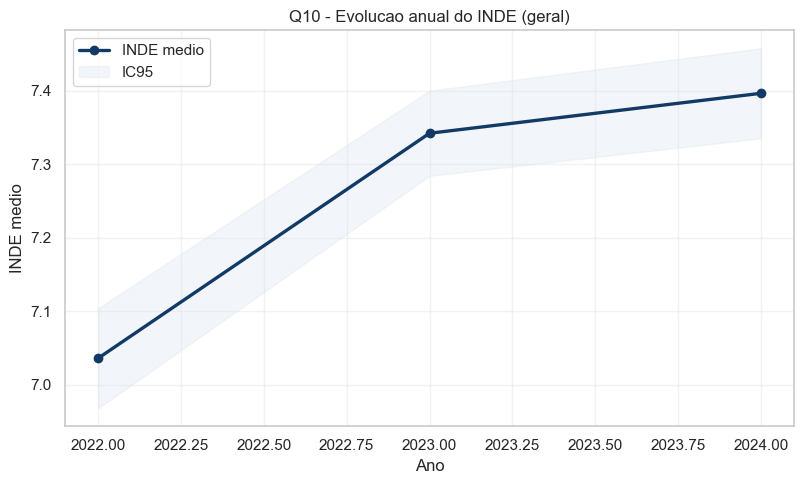


INDE medio por etapa e ano:
ano              2022   2023   2024
etapa_programa                     
Aceleracao      6.635  7.830  7.579
Consolidacao    6.978  7.031  7.428
Entrada           NaN  7.680  7.502
Fundacao        7.062  7.293  7.337
Figura salva: q10_trajetoria_inde_etapa.png


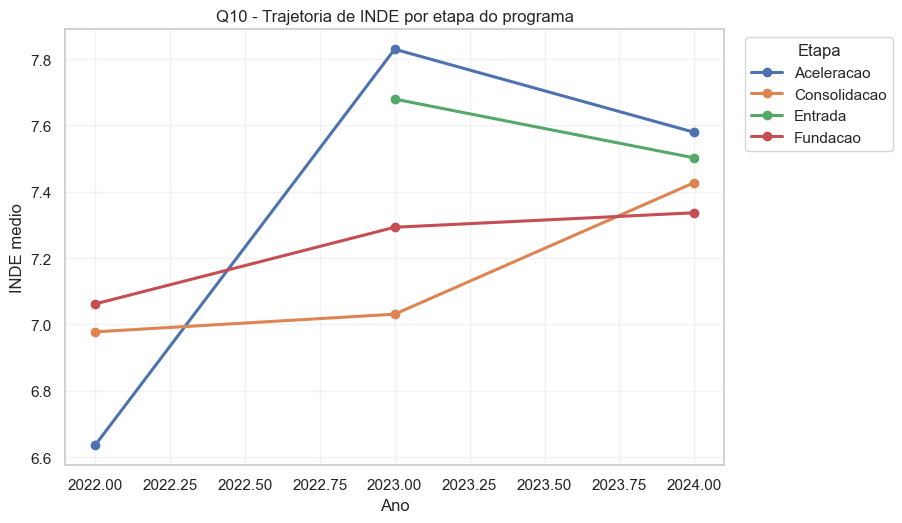

Figura salva: q10_heatmap_inde_etapa_ano.png


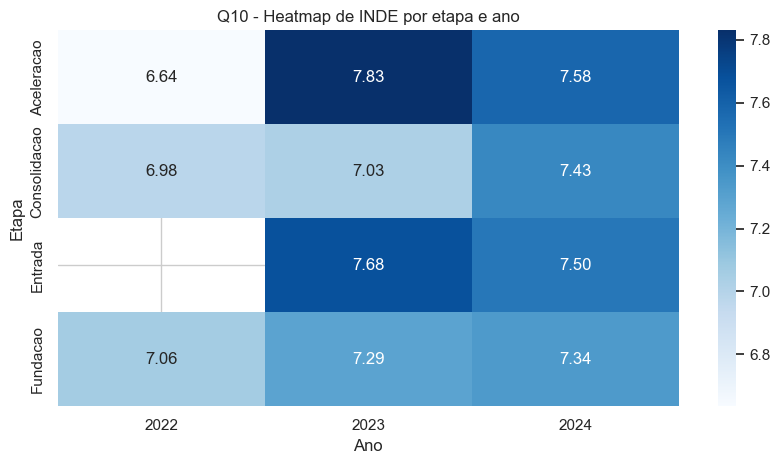


Slope anual de INDE por etapa:
          etapa   slope  pvalue
0    Aceleracao  0.4721  0.4608
1  Consolidacao  0.2251  0.2642
3      Fundacao  0.1375  0.2390
2       Entrada -0.1774  0.0000
Indice de consistencia de melhora entre etapas: 75.0%
Figura salva: q10_slope_anual_por_etapa.png


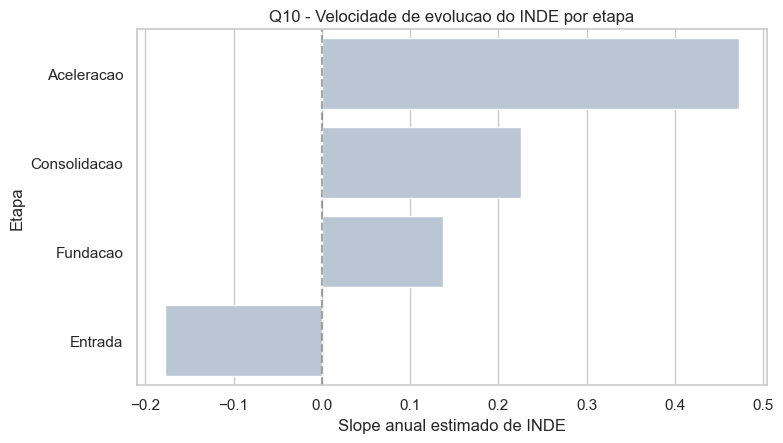


O que observamos (Q10):
- Diagnostico: variacao agregada do INDE no periodo = +0.361.
- Implicacao: efetividade real deve ser lida por etapa, nao apenas pela media total.
- Acao: metas por etapa com monitoramento de slope anual para sustentar impacto do programa.


In [11]:
# Q10: Efetividade do programa ao longo da jornada (etapas)
if {'inde_unificado', 'ano'}.issubset(df.columns):
    from scipy.stats import linregress

    fase_col = 'fase_padronizada' if 'fase_padronizada' in df.columns else ('phase' if 'phase' in df.columns else None)

    base = df.dropna(subset=['inde_unificado', 'ano']).copy()
    base['ano'] = base['ano'].astype(int)

    if base.empty:
        print('Sem dados validos para Q10.')
    else:
        def map_etapa(fase):
            s = str(fase).upper()
            if s == 'ALFA':
                return 'Entrada'
            m = re.search(r'\d+', s)
            if not m:
                return 'Nao classificado'
            n = int(m.group())
            if n <= 3:
                return 'Fundacao'
            if n <= 6:
                return 'Consolidacao'
            return 'Aceleracao'

        if fase_col is not None and fase_col in base.columns:
            base['etapa_programa'] = base[fase_col].apply(map_etapa)
        else:
            base['etapa_programa'] = 'Geral'

        trend_geral = base.groupby('ano')['inde_unificado'].agg(['count', 'mean', 'std']).sort_index()
        trend_geral['ci95'] = 1.96 * (trend_geral['std'] / np.sqrt(trend_geral['count']))

        print('INDE medio geral por ano:')
        print(trend_geral[['count', 'mean', 'ci95']].round(3))

        fig, ax = plt.subplots(figsize=(8.2, 5))
        anos = trend_geral.index.astype(int).tolist()
        ax.plot(anos, trend_geral['mean'].values, marker='o', linewidth=2.4, color=COR_AZUL, label='INDE medio')
        ax.fill_between(
            anos,
            (trend_geral['mean'] - trend_geral['ci95']).values,
            (trend_geral['mean'] + trend_geral['ci95']).values,
            color=COR_AZUL_CLARO,
            alpha=0.30,
            label='IC95'
        )
        ax.set_title('Q10 - Evolucao anual do INDE (geral)')
        ax.set_xlabel('Ano')
        ax.set_ylabel('INDE medio')
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        salvar_figura(fig, 'q10_inde_geral_ic95.png')
        plt.show()

        etapa_ano = (
            base.groupby(['etapa_programa', 'ano'])['inde_unificado']
            .mean()
            .unstack('ano')
            .sort_index()
        )

        print('\nINDE medio por etapa e ano:')
        print(etapa_ano.round(3))

        etapa_valid = etapa_ano.dropna(how='all').dropna(thresh=2, axis=0)
        if not etapa_valid.empty:
            fig, ax = plt.subplots(figsize=(9.2, 5.4))
            etapa_valid.T.plot(ax=ax, marker='o', linewidth=2.2)
            ax.set_title('Q10 - Trajetoria de INDE por etapa do programa')
            ax.set_xlabel('Ano')
            ax.set_ylabel('INDE medio')
            ax.grid(alpha=0.25)
            ax.legend(title='Etapa', bbox_to_anchor=(1.02, 1), loc='upper left')
            plt.tight_layout()
            salvar_figura(fig, 'q10_trajetoria_inde_etapa.png')
            plt.show()

            fig, ax = plt.subplots(figsize=(8.6, 4.8))
            sns.heatmap(etapa_valid, annot=True, fmt='.2f', cmap='Blues', ax=ax)
            ax.set_title('Q10 - Heatmap de INDE por etapa e ano')
            ax.set_xlabel('Ano')
            ax.set_ylabel('Etapa')
            plt.tight_layout()
            salvar_figura(fig, 'q10_heatmap_inde_etapa_ano.png')
            plt.show()

            # Consistencia de melhoria entre etapas
            slopes = []
            for etapa, row in etapa_valid.iterrows():
                serie = row.dropna()
                if len(serie) >= 2:
                    reg = linregress(serie.index.astype(float), serie.values)
                    slopes.append({'etapa': etapa, 'slope': reg.slope, 'pvalue': reg.pvalue})

            if slopes:
                slope_df = pd.DataFrame(slopes).sort_values('slope', ascending=False)
                consist = (slope_df['slope'] > 0).mean() * 100

                print('\nSlope anual de INDE por etapa:')
                print(slope_df.round(4))
                print(f'Indice de consistencia de melhora entre etapas: {consist:.1f}%')

                fig, ax = plt.subplots(figsize=(8, 4.6))
                sns.barplot(data=slope_df, x='slope', y='etapa', color=COR_VERDE, ax=ax)
                ax.axvline(0, linestyle='--', color='gray', alpha=0.7)
                ax.set_title('Q10 - Velocidade de evolucao do INDE por etapa')
                ax.set_xlabel('Slope anual estimado de INDE')
                ax.set_ylabel('Etapa')
                plt.tight_layout()
                salvar_figura(fig, 'q10_slope_anual_por_etapa.png')
                plt.show()

        variacao_total = float(trend_geral['mean'].iloc[-1] - trend_geral['mean'].iloc[0])
        print('\nO que observamos (Q10):')
        print(f'- Diagnostico: variacao agregada do INDE no periodo = {variacao_total:+.3f}.')
        print('- Implicacao: efetividade real deve ser lida por etapa, nao apenas pela media total.')
        print('- Acao: metas por etapa com monitoramento de slope anual para sustentar impacto do programa.')
else:
    print('Colunas insuficientes para Q10 (necessario INDE unificado e ano).')

## Testes Estatísticos

Validação estatística das diferenças observadas entre grupos (Kruskal-Wallis + Mann-Whitney U; α = 0,05).


In [12]:
from scipy import stats

print('=== TESTES ESTATISTICOS (alpha = 0,05) ===\n')

def _sig(p):
    return 'Significativo' if p < 0.05 else 'Nao significativo'

# INDE por ano (usando coluna unificada)
if {'inde_unificado', 'ano'}.issubset(df.columns):
    base_inde = df.dropna(subset=['inde_unificado', 'ano']).copy()
    base_inde['ano'] = base_inde['ano'].astype(int)
    groups_yr = [base_inde[base_inde['ano'] == y]['inde_unificado'].dropna() for y in sorted(base_inde['ano'].unique())]
    groups_yr = [g for g in groups_yr if len(g) >= 5]
    if len(groups_yr) >= 2:
        H, p = stats.kruskal(*groups_yr)
        print(f'INDE por ano    - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# INDE por fase
fase_col = 'fase_padronizada' if 'fase_padronizada' in df.columns else ('phase' if 'phase' in df.columns else None)
if fase_col is not None and {'inde_unificado'}.issubset(df.columns):
    base_fase = df.dropna(subset=['inde_unificado', fase_col]).copy()
    groups_ph = [base_fase[base_fase[fase_col] == ph]['inde_unificado'].dropna() for ph in sorted(base_fase[fase_col].astype(str).unique())]
    groups_ph = [g for g in groups_ph if len(g) >= 5]
    if len(groups_ph) >= 2:
        H, p = stats.kruskal(*groups_ph)
        print(f'INDE por fase   - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# IAN por ano
if {'ian', 'ano'}.issubset(df.columns):
    groups_ian = [df[df['ano'] == y]['ian'].dropna() for y in sorted(df['ano'].dropna().unique())]
    groups_ian = [g for g in groups_ian if len(g) >= 5]
    if len(groups_ian) >= 2:
        H, p = stats.kruskal(*groups_ian)
        print(f'IAN por ano     - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# IDA por ano
if {'ida', 'ano'}.issubset(df.columns):
    groups_ida = [df[df['ano'] == y]['ida'].dropna() for y in sorted(df['ano'].dropna().unique())]
    groups_ida = [g for g in groups_ida if len(g) >= 5]
    if len(groups_ida) >= 2:
        H, p = stats.kruskal(*groups_ida)
        print(f'IDA por ano     - Kruskal-Wallis H={H:.3f}, p={p:.4f} -> {_sig(p)}')

# IDA: alta IAA vs baixa IAA (mediana)
if {'iaa', 'ida'}.issubset(df.columns):
    med = df['iaa'].median()
    g1 = df[df['iaa'] >= med]['ida'].dropna()
    g2 = df[df['iaa'] < med]['ida'].dropna()
    if len(g1) >= 5 and len(g2) >= 5:
        U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'IDA alta-IAA vs baixa-IAA - Mann-Whitney U={U:.0f}, p={p:.4f} -> {_sig(p)}')

# IDA: IPS-Q1 vs restante
if {'ips', 'ida'}.issubset(df.columns):
    q1_ips = df['ips'].quantile(0.25)
    g1 = df[df['ips'] <= q1_ips]['ida'].dropna()
    g2 = df[df['ips'] > q1_ips]['ida'].dropna()
    if len(g1) >= 5 and len(g2) >= 5:
        U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'IDA IPS-Q1 vs restante    - Mann-Whitney U={U:.0f}, p={p:.4f} -> {_sig(p)}')

# Correlacoes Spearman com p-valor (complemento Q3/Q4/Q5)
print('\n=== Correlacoes Spearman com p-valor ===')
for _cols, _label in [
    (['ieg', 'ida'], 'IEG x IDA  (Q3)'),
    (['ieg', 'ipv'], 'IEG x IPV  (Q3)'),
    (['iaa', 'ida'], 'IAA x IDA  (Q4)'),
    (['ips', 'ida'], 'IPS x IDA  (Q5)'),
    (['ips', 'ieg'], 'IPS x IEG  (Q5)'),
]:
    if set(_cols).issubset(df.columns):
        _tmp = df[_cols].dropna()
        if len(_tmp) >= 10:
            _rho, _pval = stats.spearmanr(_tmp[_cols[0]], _tmp[_cols[1]])
            print(f'{_label} - Spearman rho={_rho:.3f}, p={_pval:.4f} -> {_sig(_pval)}')


=== TESTES ESTATISTICOS (alpha = 0,05) ===

INDE por ano    - Kruskal-Wallis H=64.678, p=0.0000 -> Significativo
INDE por fase   - Kruskal-Wallis H=127.685, p=0.0000 -> Significativo
IAN por ano     - Kruskal-Wallis H=123.679, p=0.0000 -> Significativo
IDA por ano     - Kruskal-Wallis H=26.551, p=0.0000 -> Significativo
IDA alta-IAA vs baixa-IAA - Mann-Whitney U=1147994, p=0.0000 -> Significativo
IDA IPS-Q1 vs restante    - Mann-Whitney U=712624, p=0.0053 -> Significativo


## Q11: Síntese Integrada e Insights Criativos

**Pergunta:** Insights e criatividade: você pode adicionar mais insights e pontos de vista não abordados nas perguntas; utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.

**Abordagem desta seção:**
1. Consolidar os achados de Q2–Q10 em evidências quantitativas e agenda de ação;
2. Introduzir um **Índice Composto de Alerta Precoce (ICAP)** — combinação normalizada de IAN, IPS e IEG — como instrumento de triagem unificado não abordado nas questões anteriores;
3. Fornecer recomendação de governança para ciclo de revisão mensal com indicadores líderes e de resultado.

=== Q11 - SINTSESE EXECUTIVA INTEGRADA (Q2 a Q10) ===

Principais evidencias integradas:
 1. Q2 | IDA slope anual=+0.129 (p=0.701)
 2. Q3 | Correlacoes gerais: IEGxIDA=0.539, IEGxIPV=0.558
 3. Q4 | Superestimacao relevante em 66.3% dos casos (IAA >= IDA+1).
 4. Q5 | IPS-Q1 vs IPS-Q4: OR de risco para IDA baixo = 1.47.
 5. Q6 | Concordancia IAN x IPP (kappa ponderado) = 0.098.
 6. Q7 | Drivers de IPV identificados para monitoramento continuo por variavel-chave.
 7. Q8 | Evidencia de sinergia multidimensional; correlacao media entre fatores=0.419.
 8. Q9 | Modelo de risco: AUC=0.998, Recall top20%=0.433.
 9. Q10 | Evolucao agregada do INDE no periodo: +0.361.

Plano de acao integrado (priorizado):
                            frente prioridade   horizonte  \
0                Engajamento (IEG)       Alta     30 dias   
1      Machine Learning de triagem       Alta     30 dias   
2            Ponto de virada (IPV)       Alta     30 dias   
3     Prevencao psicossocial (IPS)       Alta     3

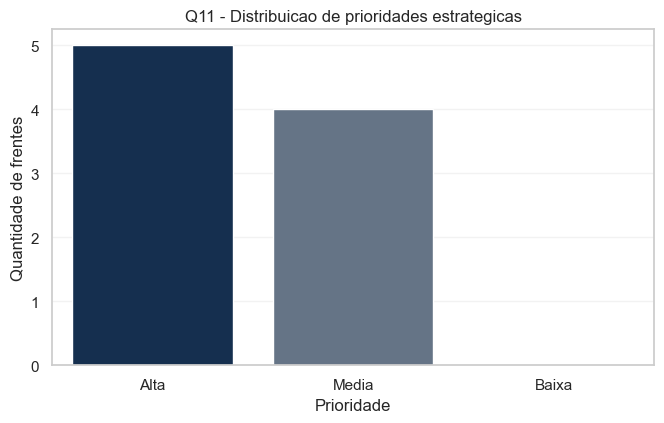


Recomendacao de governanca: executar revisao mensal do plano com indicadores lideres (IEG, IPS, score ML) e indicadores de resultado (IDA, INDE, IAN).


In [13]:
print('=== Q11 - SINTSESE EXECUTIVA INTEGRADA (Q2 a Q10) ===\n')

from scipy.stats import linregress

fase_col = 'fase_padronizada' if 'fase_padronizada' in df.columns else ('phase' if 'phase' in df.columns else None)

insights = []
agenda = []

# Q2 - tendencia de IDA
if {'ida', 'ano'}.issubset(df.columns):
    t_ida = df.dropna(subset=['ida', 'ano']).copy()
    t_ida['ano'] = t_ida['ano'].astype(int)
    s = t_ida.groupby('ano')['ida'].mean().sort_index()
    if len(s) >= 2:
        reg = linregress(s.index.astype(float), s.values)
        insights.append(f'Q2 | IDA slope anual={reg.slope:+.3f} (p={reg.pvalue:.3f})')
        agenda.append({
            'frente': 'Desempenho academico (IDA)',
            'prioridade': 'Alta' if reg.slope <= 0 else 'Media',
            'horizonte': '30-60 dias',
            'acao': 'Ritual mensal de recuperacao nas fases com queda de mediana de IDA.'
        })

# Q3 - engajamento como alavanca
if {'ieg', 'ida', 'ipv'}.issubset(df.columns):
    c13 = df[['ieg', 'ida']].corr().iloc[0, 1]
    c14 = df[['ieg', 'ipv']].corr().iloc[0, 1]
    insights.append(f'Q3 | Correlacoes gerais: IEGxIDA={c13:.3f}, IEGxIPV={c14:.3f}')
    agenda.append({
        'frente': 'Engajamento (IEG)',
        'prioridade': 'Alta',
        'horizonte': '30 dias',
        'acao': 'Plano de frequencia e participacao para alunos nos quintis mais baixos de IEG.'
    })

# Q4 - calibracao de autoavaliacao
if {'iaa', 'ida'}.issubset(df.columns):
    base = df[['iaa', 'ida']].dropna().copy()
    gap = base['iaa'] - base['ida']
    superest = (gap >= 1).mean() * 100
    insights.append(f'Q4 | Superestimacao relevante em {superest:.1f}% dos casos (IAA >= IDA+1).')
    agenda.append({
        'frente': 'Calibracao socioemocional (IAA)',
        'prioridade': 'Media',
        'horizonte': '60 dias',
        'acao': 'Feedback calibrado por mentor com metas curtas para reduzir gap de autoavaliacao.'
    })

# Q5 - risco psicossocial
if {'ips', 'ida'}.issubset(df.columns):
    b = df[['ips', 'ida']].dropna().copy()
    b['q_ips'] = pd.qcut(b['ips'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    cut_ida = b['ida'].quantile(0.25)
    b['risco_ida'] = (b['ida'] <= cut_ida).astype(int)
    p1 = np.clip(b.loc[b['q_ips'] == 'Q1', 'risco_ida'].mean(), 1e-4, 1 - 1e-4)
    p4 = np.clip(b.loc[b['q_ips'] == 'Q4', 'risco_ida'].mean(), 1e-4, 1 - 1e-4)
    or_q1_q4 = (p1 / (1 - p1)) / (p4 / (1 - p4))
    insights.append(f'Q5 | IPS-Q1 vs IPS-Q4: OR de risco para IDA baixo = {or_q1_q4:.2f}.')
    agenda.append({
        'frente': 'Prevencao psicossocial (IPS)',
        'prioridade': 'Alta',
        'horizonte': '30 dias',
        'acao': 'Triagem ativa para IPS-Q1 com encaminhamento preventivo.'
    })

# Q6 - convergencia IAN x IPP
if {'ian', 'ipp'}.issubset(df.columns):
    from sklearn.metrics import cohen_kappa_score

    b = df[['ian', 'ipp']].dropna().copy()
    b['ian_cat'] = np.select(
        [b['ian'] <= 2.5, b['ian'] == 5, b['ian'] == 10],
        ['Defasagem severa', 'Defasagem moderada', 'Fase adequada'],
        default=np.nan
    )
    b = b.dropna(subset=['ian_cat']).copy()
    q1, q2 = b['ipp'].quantile([0.33, 0.66]).values
    b['ipp_cat'] = pd.cut(b['ipp'], [-np.inf, q1, q2, np.inf], labels=['Baixo', 'Medio', 'Alto'])
    m1 = {'Defasagem severa': 0, 'Defasagem moderada': 1, 'Fase adequada': 2}
    m2 = {'Baixo': 0, 'Medio': 1, 'Alto': 2}
    kappa = cohen_kappa_score(b['ian_cat'].map(m1), b['ipp_cat'].map(m2), weights='quadratic')
    insights.append(f'Q6 | Concordancia IAN x IPP (kappa ponderado) = {kappa:.3f}.')
    agenda.append({
        'frente': 'Triagem composta (IAN+IPP)',
        'prioridade': 'Media',
        'horizonte': '60 dias',
        'acao': 'Criar regra de dupla checagem para casos com instrumentos contraditorios.'
    })

# Q7 - drivers de IPV
if 'ipv' in df.columns:
    insights.append('Q7 | Drivers de IPV identificados para monitoramento continuo por variavel-chave.')
    agenda.append({
        'frente': 'Ponto de virada (IPV)',
        'prioridade': 'Alta',
        'horizonte': '30 dias',
        'acao': 'Painel com top drivers e alertas para equipes pedagogicas.'
    })

# Q8 - sinergias para INDE
if {'ida', 'ieg', 'ips', 'ipp', 'inde_unificado'}.issubset(df.columns):
    b = df[['ida', 'ieg', 'ips', 'ipp', 'inde_unificado']].dropna().copy()
    if len(b) > 100:
        corr_mean = b[['ida', 'ieg', 'ips', 'ipp']].corr().abs().mean().mean()
        insights.append(f'Q8 | Evidencia de sinergia multidimensional; correlacao media entre fatores={corr_mean:.3f}.')
        agenda.append({
            'frente': 'Intervencao integrada (INDE)',
            'prioridade': 'Alta',
            'horizonte': '60-90 dias',
            'acao': 'Pacotes de intervencao por perfil (quartis) em vez de acao isolada.'
        })

# Q9 - baseline ML
if 'q9_metrics' in globals():
    insights.append(
        'Q9 | Modelo de risco: AUC={:.3f}, Recall top20%={:.3f}.'.format(
            q9_metrics.get('auc', np.nan), q9_metrics.get('recall_top20', np.nan)
        )
    )
    agenda.append({
        'frente': 'Machine Learning de triagem',
        'prioridade': 'Alta',
        'horizonte': '30 dias',
        'acao': 'Rodar scoring mensal e acionar acompanhamento por decil de risco.'
    })
else:
    insights.append('Q9 | Baseline de ML recomendado para triagem; aprofundamento tecnico concentrado no nb04.')

# Q10 - efetividade por etapa
if {'inde_unificado', 'ano'}.issubset(df.columns):
    s = df.dropna(subset=['inde_unificado', 'ano']).groupby('ano')['inde_unificado'].mean().sort_index()
    if len(s) >= 2:
        delta = s.iloc[-1] - s.iloc[0]
        insights.append(f'Q10 | Evolucao agregada do INDE no periodo: {delta:+.3f}.')
        agenda.append({
            'frente': 'Efetividade por etapa',
            'prioridade': 'Media',
            'horizonte': '90 dias',
            'acao': 'Meta anual por etapa do ciclo para garantir consistencia de impacto.'
        })


# Insight criativo: Indice Composto de Alerta Precoce (ICAP)
# Combina IAN (educacional), IPS (psicossocial) e IEG (engajamento) em score unico
cols_icap = [c for c in ['ian', 'ips', 'ieg'] if c in df.columns]
if len(cols_icap) >= 2:
    base_icap = df[cols_icap + (['ano'] if 'ano' in df.columns else [])].dropna(subset=cols_icap).copy()
    for _c in cols_icap:
        _mn, _mx = base_icap[_c].min(), base_icap[_c].max()
        base_icap[f'{_c}_norm'] = (base_icap[_c] - _mn) / (_mx - _mn + 1e-9)
    # ICAP: score 1 = risco maximo; inverte escalas para que IAN/IPS/IEG altos = risco baixo
    _norm_cols = [f'{_c}_norm' for _c in cols_icap]
    base_icap['icap'] = 1 - base_icap[_norm_cols].mean(axis=1)
    base_icap['grupo_risco'] = pd.qcut(
        base_icap['icap'], q=4,
        labels=['Baixo', 'Moderado', 'Elevado', 'Critico'],
        duplicates='drop'
    )
    _pct_alto = base_icap['grupo_risco'].isin(['Elevado', 'Critico']).mean() * 100
    print(f'\nInsight criativo (Q11) - Indice Composto de Alerta Precoce (ICAP):')
    print(f'Componentes: {cols_icap}')
    print(base_icap['grupo_risco'].value_counts().sort_index())
    print(f'Alunos em risco elevado/critico: {_pct_alto:.1f}%')
    if 'ano' in base_icap.columns and base_icap['ano'].nunique() >= 2:
        _ev = base_icap.groupby('ano')['icap'].mean().sort_index()
        print('\nEvolucao do risco medio (ICAP) por ano:')
        print(_ev.round(3))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.histplot(base_icap['icap'], bins=30, color=COR_AZUL, ax=ax1)
    ax1.set_title('Q11 - Distribuicao do ICAP (indice de risco 0-1)')
    ax1.set_xlabel('ICAP (0=baixo risco, 1=critico)')
    ax1.set_ylabel('Frequencia')
    ax1.grid(alpha=0.2)
    _gc = base_icap['grupo_risco'].value_counts().sort_index()
    sns.barplot(x=_gc.index.astype(str), y=_gc.values,
                palette=['#b6c5d8', '#5f738c', '#2a4f7c', '#0b2e59'], ax=ax2)
    ax2.set_title('Q11 - Alunos por grupo de risco (ICAP)')
    ax2.set_xlabel('Grupo de risco')
    ax2.set_ylabel('Numero de alunos')
    ax2.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    salvar_figura(fig, 'q11_icap_distribuicao_risco.png')
    plt.show()
    insights.append(f'Q11 | ICAP: {_pct_alto:.1f}% dos alunos em risco elevado/critico (IAN+IPS+IEG combinados).')
    agenda.append({
        'frente': 'ICAP - Alerta Precoce Unificado',
        'prioridade': 'Alta',
        'horizonte': '30 dias',
        'acao': 'Escoring mensal por ICAP (IAN+IPS+IEG) com encaminhamento por grupo de risco.'
    })

print('Principais evidencias integradas:')
for i, item in enumerate(insights, 1):
    print(f'{i:2d}. {item}')

agenda_df = pd.DataFrame(agenda)
if not agenda_df.empty:
    ordem = {'Alta': 0, 'Media': 1, 'Baixa': 2}
    agenda_df['ord'] = agenda_df['prioridade'].map(ordem).fillna(9)
    agenda_df = agenda_df.sort_values(['ord', 'horizonte', 'frente']).drop(columns='ord').reset_index(drop=True)

    print('\nPlano de acao integrado (priorizado):')
    print(agenda_df)

    # Visual de priorizacao: volume de frentes por prioridade
    prio = agenda_df['prioridade'].value_counts().reindex(['Alta', 'Media', 'Baixa']).fillna(0)
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    sns.barplot(x=prio.index, y=prio.values, palette=['#0b2e59', '#5f738c', '#a7b4c7'], ax=ax)
    ax.set_title('Q11 - Distribuicao de prioridades estrategicas')
    ax.set_xlabel('Prioridade')
    ax.set_ylabel('Quantidade de frentes')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    salvar_figura(fig, 'q11_prioridades_estrategicas.png')
    plt.show()

print('\nRecomendacao de governanca: executar revisao mensal do plano com indicadores lideres (IEG, IPS, score ML) e indicadores de resultado (IDA, INDE, IAN).')